In [1]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from pybiomart import Dataset
import networkAnalysisUtilities as nAU
import fusionGeneAnalysis
import dansy
import uniprotIDMapping as unimapping
from chimerdb_cleanup_utilities import *

In [2]:
# Creating some default parameters for future plots.
plt.rcParams['font.size'] = 8
plt.rcParams['axes.labelsize'] = 6
plt.rcParams['axes.linewidth'] = 0.5
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.pad_inches'] = 0.01
plt.rcParams['lines.markeredgewidth'] = 0.01
plt.rcParams['figure.dpi'] = 200



### Importing necessary databases and useful files

In [3]:
gene_ID_conv_clean = pd.read_csv('ENSEMBL_Gene_Conversion.csv')

In [4]:
# To start I am just going to work with the GBM dataset
chimerdb = pd.read_excel('ChimerSeq4.xlsx')
chimerdb['H_gene'] = chimerdb.apply(fix_datetime_names,args = ['Fusion_pair','H_gene',0],axis=1)
chimerdb['T_gene'] = chimerdb.apply(fix_datetime_names,args = ['Fusion_pair','T_gene',1],axis=1)

In [5]:
cancersOI = ['GBM','LAML','PAAD','LUAD','PRAD','OV','THCA','LGG','LUSC','BRCA','UCS','UCEC','KICH','KIRC','KIRP','LIHC','COAD','CHOL','CESC','PCPG','TGCT','SKCM','ESCA','HNSC','BLCA','STAD','SARC','ACC','DLBC','MESO','READ','THYM','UVM']
fusion_info = fusionGeneAnalysis.retrieve_cancer_fusion_data(chimerdb, cancersOI)
full_gene_list = set(fusion_info.H_gene).union(fusion_info.T_gene)
print(f'There are a total of {len(full_gene_list)} genes being assessed.')

There are a total of 10960 genes being assessed.


In [6]:
full_exon_information = pd.read_csv('Gene_exon_information.csv')

Below here is testing the full function performance to ensure everything still works.

In [7]:
# Importing the full proteome n-gram analysis
ref_df = dansy.import_proteome_files(ref_file_dir='data/Current_Human_Proteome',
                                       ref_file_suffix='Jan7_2025.csv')
proteome_net = dansy.dansy(ref=ref_df, n=66)

Starting to fetch n-grams.
Finished getting all n-grams
Starting to generate adjacency
Finished building adjacency.


In [8]:
# Getting the full set of naturally occuring n-grams to pass on to the fusion gene analysis
nat_ngrams_ids = set(proteome_net.ngrams).union(proteome_net.collapsed_ngrams)
interpro_dict = proteome_net.interpro_conversion

# Generate the network for the original canonical human proteome
G = proteome_net.G

# Get a couple of key parameters that can potentially change
cc_orig = nx.number_connected_components(G)
isol_orig = nx.number_of_isolates(G)
artic_orig = len(list(nx.articulation_points(G)))

proteome_gross_topo = [cc_orig, isol_orig, artic_orig]
ref_data = [ref_df, proteome_net.adj, proteome_net.collapsed_ngrams, interpro_dict, proteome_gross_topo]

This is to check how the new version of the function works relative to the old version. I am expecting the same final results, but different times

In [49]:
import importlib
importlib.reload(fusionGeneAnalysis)

<module 'fusionGeneAnalysis' from '/Users/yzv6ek/Documents/GitHub/Naegle Lab/DANSy_Applications/fusionGeneAnalysis.py'>

In [9]:

ver1_fusion_categories, ver1_pts,ver1_gc = fusionGeneAnalysis.perform_fusion_analysis(chimerdb, cancersOI,gene_ID_conv_clean,ref_data)


Generating reference network
Retrieving Ensembl IDs of interest
Adding exon and peptide information
There were 1346 fusion(s) dropped from further analysis due to missing gene information
There were 776 fusions that the gene name had to be changed to upppercase
There were 5139 patient(s) had a mismatch of strand information
There were 981 fusions with a UTR region as part of the fusion.
Due to missing uniprot information 168 fusion(s) were removed
There were 164 fusions that were removed due to domain annotations.
Reduced the network change calculation to 5391 unique architectures from 44370.
Determining changes in the fusion network


100%|██████████| 5391/5391 [1:15:46<00:00,  1.19it/s] 


There were 2222 architecture(s) skipped due to presence in the original adjacency matrix.
Simple Gross Network Summary Generation


In [50]:

fusion_categories, pts,gc = fusionGeneAnalysis.perform_fusion_analysis(chimerdb, cancersOI,gene_ID_conv_clean,ref_data, version=2, dansy_obj=proteome_net)

Generating reference network
Retrieving Ensembl IDs of interest
Adding exon and peptide information
There were 1346 fusion(s) dropped from further analysis due to missing gene information
There were 776 fusions that the gene name had to be changed to upppercase
There were 5139 patient(s) had a mismatch of strand information
There were 981 fusions with a UTR region as part of the fusion.
Due to missing uniprot information 168 fusion(s) were removed
There were 164 fusions that were removed due to domain annotations.
Reduced the network change calculation to 5430 unique architectures from 44370.
Determining changes in the fusion network


100%|██████████| 5430/5430 [00:12<00:00, 433.40it/s]


There were 2243 architecture(s) skipped due to presence in the original adjacency matrix.
Simple Gross Network Summary Generation


Now I am loading the previous results and checking how they differ or if any that were previously analyzed have been omitted.

In [11]:
import json

json_file = 'Fusion Patient Complete Information.json'
with open(json_file) as j_file:
    prior_res = json.load(j_file)

In [73]:
mismatch_res = []
missing_res = []
for p in prior_res.keys():
    q = prior_res[p]['Interpro Domain Architecture IDs']
    if int(p) in list(pts.keys()):
        new_q = pts[int(p)]['Interpro Domain Architecture IDs']
        if q != new_q:
            mismatch_res.append(p)
    else:
        missing_res.append(p)
    
print(f'There are {len(mismatch_res)} fusions whose final domain architecture does not match')
print(f'There are {len(missing_res)} fusions that were lost.')

There are 107 fusions whose final domain architecture does not match
There are 0 fusions that were lost.


Some spot checking of the mismatches suggest that the mismatch is due to updated InterPro domain annotations. So I will be checking these now.

In [75]:
prot_info_changes = set()
prot_info_depend = 0
neg_prob = 0
dbl_check = []
for p in mismatch_res:
    genes = prior_res[p]['Genes']
    cur_genes = pts[int(p)]['Genes']
    dep_flag = False
    neg = False
    for g,info in genes.items():
        prior_arch = info['Interpro Domain Architecture IDs']
        if g in cur_genes:
            cur_arch = cur_genes[g]['Interpro Domain Architecture IDs']
        else:
            for cg, cinfo in cur_genes.items():
                if cinfo['Gene'] == info['Gene']:
                    cur_arch = cinfo['Interpro Domain Architecture IDs']

        if cur_arch != prior_arch:
            prot_info_changes.add(g)
            dep_flag = True
    
        if info['Fusion peptide length'] < 0:
            neg = True

    if dep_flag:
        prot_info_depend += 1
    elif neg:
        neg_prob += 1
    else:
        dbl_check.append(p)
        
        
print(f'Changes in domain annotation info: {prot_info_depend}')
print(f'Issue due to negative aa positions: {neg_prob}')
print(f'There are {len(dbl_check)} fusions that should be double checked for exon inclusion or amino acid buffer issues.')


Changes in domain annotation info: 0
Issue due to negative aa positions: 14
There are 93 fusions that should be double checked for exon inclusion or amino acid buffer issues.


After a couple of different runs I have found the following:

- When run with a new reference file the patients that are mismatching are almost entirely due to updates in domain boundaries in Interpro
- When looking at the updated reference files there are still some genes that were not properly converted so I ended up getting a list of all proteins and their gene names from UniProt to build a new reference file on Jan 8th.
- For the ~100 fusions that are completely mismatched, about 60 of these are changed due to me adding in a buffer region at the end of domain limit annotations to give some leeway in how imprecise those can be in InterPro for individual proteins and for how inexact they can be. (verified by changing the buffer region and rerunning)
- For the ~30 that are left, the update in methods for mapping exons to peptides that corrected some issues resulting to compounding effects of strand and fusion position specifics that resulted in either negative values for the amino acid position/contribution or led to the truncation of an exon that was supposed to be included but not being applied to the prior exon.


Now let's look at the missing impacts on the network to verify not too many changed, but expecting some due to slight changes in exon conversions and now the updates to the reference file.

In [76]:
json_file = 'Fusion Patient Fusion Categories.json'
with open(json_file) as j_file:
    prior_fusion_categories = json.load(j_file)

In [77]:
# Now let's compare both versions of the fusion categories with the prior one. I'm expecting only one that changed (the one that mapped to the wrong chromosome in the past.)


mismatch_cats = {}
for can,can_fusions in prior_fusion_categories.items():
    cancer_mismatches = {}
    for cat, cat_details in can_fusions.items():
        if cat in prior_fusion_categories[can]:
            past_results = cat_details['Pt Members']
            cur_results = fusion_categories[can][cat]['Pt Members']
            x = set(past_results).difference(cur_results)
            # Check that there is a complete overlap in the past results in the current results (which have more than the past since including the hg19 mapped results)

            if len(x) >= 1:
                # Check if they moved into the Reintroduction category which did not exist before
                if all(i in fusion_categories[can]['Reintroduction']['Pt Members'] for i in x):
                    pass
                else:
                    cancer_mismatches[cat] = x
                    print(f'Cancer: {can} for category: {cat} has mismatches')
    mismatch_cats[can] = cancer_mismatches


Cancer: GBM for category: No Change has mismatches
Cancer: LUAD for category: No Change has mismatches
Cancer: LUAD for category: Empty Domain has mismatches
Cancer: PRAD for category: No Change has mismatches
Cancer: PRAD for category: Interconnectedness has mismatches
Cancer: PRAD for category: Empty Domain has mismatches
Cancer: OV for category: Interconnectedness has mismatches
Cancer: OV for category: Empty Domain has mismatches
Cancer: LGG for category: Empty Domain has mismatches
Cancer: LUSC for category: No Change has mismatches
Cancer: LUSC for category: Empty Domain has mismatches
Cancer: BRCA for category: No Change has mismatches
Cancer: BRCA for category: Interconnectedness has mismatches
Cancer: BRCA for category: Empty Domain has mismatches
Cancer: UCS for category: Interconnectedness has mismatches
Cancer: UCS for category: Empty Domain has mismatches
Cancer: UCEC for category: No Change has mismatches
Cancer: UCEC for category: Interconnectedness has mismatches
Cancer

In [83]:
mismatch_cats['LUAD']['No Change']

{93859, 93913}

In [92]:
93859 in prior_fusion_categories['LUAD']['No Change']['Pt Members']

True

In [ ]:
i =93859
for cat,cat_details in fusion_categories['LUAD'].items():
    if i in cat_details['Pt Members']:
        print(f'Fusion {i} is now {cat}, but was No Change before')

i = 101264
for cat,cat_details in fusion_categories['SARC'].items():
    if i in cat_details['Pt Members']:
        print(f'Fusion {i} is now {cat}, but was Interconnected before')

i = 90074
for cat,cat_details in fusion_categories['HNSC'].items():
    if i in cat_details['Pt Members']:
        print(f'Fusion {i} is now {cat}, but was No Change before')

Fusion 93859 is now Interconnectedness, but was No Change before
Fusion 101264 is now Connect Components, but was Interconnected before
Fusion 90074 is now Empty Domain, but was No Change before


Not fusion 90074 was the VAMP7 fusion that misattributed to the X chromosome rather than Y like it was supposed to be based on it's breakpoint location.

For fusion 101264 it looks like was related to the exon inclusion/truncation issue from before.

# ChimerDB cleanup issues

Now one of the other small things I noticed about the ChimerDB that needs to be addressed is that several of the fusions are for the same patient but from "different" samples. Some of these samples are the base patient ID and others are the full sample ID, but it is always the same as shown below. THe only difference between the fusions is the potential location of the breakpoint.

In [93]:
# an example of the same patient with the same fusion

chimerdb[(chimerdb['BarcodeID'] == 'TCGA-E8-A432-01A') & (chimerdb['Fusion_pair'] == 'EML4-ALK')].filter(['id', 'Source','H_gene', 'H_position','T_gene','T_position','Frame','Highly_Reliable_Seq'])

,id,Source,H_gene,H_position,T_gene,T_position,Frame,Highly_Reliable_Seq
53952,53953,STARFusion,EML4,42492091,ALK,29449940,Out-of-frame,Seq+
53953,53954,STARFusion,EML4,42491871,ALK,29449940,In-Frame,Seq+
53954,53955,STARFusion,EML4,42491871,ALK,29450538,In-Frame,Seq+
53955,53956,STARFusion,EML4,42492091,ALK,29450538,Out-of-frame,Seq+
62048,62049,PRADA(TumorFusion),EML4,42492091,ALK,29449940,Out-of-frame,Seq+
104963,104964,TCGA FAWG,EML4,42264951,ALK,29227074,Out-of-frame,Seq+


In this case the patient has one fusion that is found multiple times with different breakpoints and different frames. Even after filtering the fusions to those that remain in frame the ALK gene has two breakpoints that are being found one at 29449940 and the other at 29450538. Currently, the analysis would treat these as the same, but let's look at the exon information to see if these produce functionally different fusions or not.

Note the breakpoints are from hg19 coordinates so when we do a liftover they are: 29227074 and 29227672

In [95]:
ensemblOI = 'ENSG00000143924'
full_exon_information[full_exon_information['Gene stable ID'] == ensemblOI].sort_values('CDS start').drop(['Strand', 'CDS end'], axis = 1)

,Gene stable ID,Exon region start (bp),Exon region end (bp),CDS start,Genomic coding start,Genomic coding end
197728,ENSG00000143924,42169353,42169636,1.0,42169612.0,42169636.0
197729,ENSG00000143924,42245505,42245687,26.0,42245505.0,42245687.0
197730,ENSG00000143924,42256501,42256630,209.0,42256501.0,42256630.0
197731,ENSG00000143924,42261121,42261294,339.0,42261121.0,42261294.0
197732,ENSG00000143924,42263178,42263306,513.0,42263178.0,42263306.0
197733,ENSG00000143924,42264706,42264731,642.0,42264706.0,42264731.0
197734,ENSG00000143924,42280850,42280973,668.0,42280850.0,42280973.0
197735,ENSG00000143924,42282823,42282972,792.0,42282823.0,42282972.0
197736,ENSG00000143924,42284634,42284703,942.0,42284634.0,42284703.0
197737,ENSG00000143924,42286269,42286379,1012.0,42286269.0,42286379.0


This leads to only one exon difference between them so this would represent two potential different fusion proteins but from the same sample and representing the same fusion. In essence these are two different isoforms, but this is coming from the same program.

If I start to look at different programs used to detect the fusions things get a little more complicated.

Let's look at the TCGA patient with the ID "TCGA-67-6215" and grab both the parent ID and the sample ID that ends with -01A.

In [96]:
chimerdb[(chimerdb['BarcodeID'].isin(['TCGA-67-6215','TCGA-67-6215-01A'])) & (chimerdb['Fusion_pair'] == 'EML4-ALK')].filter(['id', 'Source','H_gene', 'H_position','T_gene','T_position','Frame','Highly_Reliable_Seq'])

,id,Source,H_gene,H_position,T_gene,T_position,Frame,Highly_Reliable_Seq
7546,7547,FusionScan,EML4,42491871,ALK,29446394,In-Frame,Seq+
35094,35095,STARFusion,EML4,42491871,ALK,29446394,In-Frame,Seq+
62044,62045,PRADA(TumorFusion),EML4,42491871,ALK,29446394,In-Frame,Seq+
77023,77024,Tophat-Fusion,EML4,42491870,ALK,29446393,In-Frame,Seq+
93936,93937,TCGA FAWG,EML4,42264731,ALK,29223528,In-Frame,Seq+


In [51]:
proteome_net.retrieve_protein_info(prot='P43268')

,UniProt ID,Gene,Species,Uniprot Domains,Ref Sequence,PDB IDs,Uniprot Domain Architecture,Interpro Domains,Interpro Domain Architecture,Interpro Domain Architecture IDs
19188,P43268,ETV4,Homo sapiens,,MERRMKAGYLDQQVPYTFSSKSPGNGSLREALIGPLGKLMDPGSLP...,4CO8;4UUV;5ILU,,ETS_PEA3_N:IPR006715:7:339;Ets_dom:IPR000418:3...,ETS_PEA3_N|Ets_dom,IPR006715|IPR000418


This again is the same patient (and likely the same sample), but the fusion was detected with 5 of the tools. However, in my analysis these are all treated differently because I only drop duplicates that include the Source column. So the source is going to keep them distinct. However, this also points out one more issue. Even if I remove the source column, the Tophat-Fusion analysis has a "different" breakpoint. The breakpoint is a single base pair different than the rest. And this is a recurring thing I have noticed throughout suggesting that the Tophat-Fusion program runs with 0-indexing, while the rest run with 1-indexing. Thus, I need to fix that up too...

So, below I will be cleaning up the data a little bit more and trying to aggregate data as I can to remove duplicated/unnecessary information from the somewhat cleaned dataset to start. The cleaner functions are found in [chimerdb_cleanup_utilities](chimerdb_cleanup_utilities.py) which include the following functions:
- check_for_tophat*
- check_tophat_pos
- compare_hg19_hg38
- inner_hg_build_comp
- check_for_collapsing*
- fix_datetime_names

The functions with * are used in this script the rest are internal functions

In [7]:
import liftover
from collections import Counter
import seaborn as sns

In [8]:
# First let's tackle the Tophat-Fusion issue. I will check that for every common fusion with a Tophat-fusion source and a secondary one is actually off by one

# Limiting the analysis to everything that is not an out-of-frame fusion
chimer_filt = fusionGeneAnalysis.retrieve_cancer_fusion_data(chimerdb, cancersOI)

# Now grouping based on the fusion pair and the Barcode ID to find the unique potential ones
grouped_db = chimer_filt.groupby(['BarcodeID', 'Fusion_pair'])
grouped_db.get_group(('TCGA-67-6215-01A','EML4-ALK'))

,id,ChimerDB_Type,Source,webSource,Fusion_pair,H_gene,H_chr,H_position,H_strand,T_gene,...,H_transcription_factor,T_locus,T_kinase,T_oncogene,T_tumor_suppressor,T_receptor,T_transcription_factor,ChimerKB,ChimerPub,Highly_Reliable_Seq
35094,35095,ChimerSeq,STARFusion,TCGA_RNA-Seq,EML4-ALK,EML4,chr2,42491871,+,ALK,...,NaN,p23.1,TK:ALK,Oncogene,NaN,NaN,NaN,KB,Pub,Seq+
62044,62045,ChimerSeq,PRADA(TumorFusion),TCGA_RNA-Seq,EML4-ALK,EML4,chr2,42491871,-,ALK,...,NaN,p23.1,TK:ALK,Oncogene,NaN,NaN,NaN,KB,Pub,Seq+
77023,77024,ChimerSeq,Tophat-Fusion,TCGA_RNA-Seq,EML4-ALK,EML4,chr2,42491870,+,ALK,...,NaN,p23.1,TK:ALK,Oncogene,NaN,NaN,NaN,KB,Pub,Seq+
93936,93937,ChimerSeq,TCGA FAWG,TCGA_RNA-Seq,EML4-ALK,EML4,chr2,42264731,+,ALK,...,NaN,p23.1,TK:ALK,Oncogene,NaN,NaN,NaN,KB,Pub,Seq+


In [9]:
chimer_filt.Genome_Build_Version

5         hg19
8         hg19
10        hg19
11        hg19
14        hg19
          ... 
132972    hg38
132973    hg38
132974    hg38
132975    hg38
132976    hg38
Name: Genome_Build_Version, Length: 45884, dtype: object

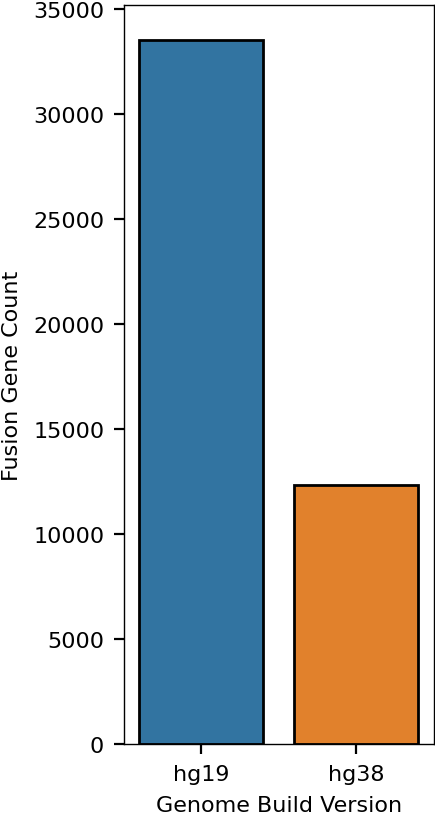

In [10]:
sns.countplot(chimer_filt, x = 'Genome_Build_Version', hue = 'Genome_Build_Version',edgecolor = 'k', linewidth=1)
plt.xlabel('Genome Build Version', size = 8)
plt.ylabel('Fusion Gene Count', size = 8)
plt.gcf().set_figwidth(2)
plt.show()

In [11]:
converter = liftover.get_lifter('hg19', 'hg38', one_based=True)

In [12]:
idxkeepers = []
codes = []
closerlook = []
for group in grouped_db.groups.keys():
    x,status = check_for_collapsing(grouped_db.get_group(group), converter)
    idxkeepers.append(x)
    codes.append(status)
    if status == 0:
        closerlook.append(group)
        
code_mapper = {6:'Single', 1:'Tophat Collapse', 2: 'hg38 Overlap kept', 8:'Multiple hg38 breakpoints',7:'Multiple hg19 breakpoints tophat collapse', 3:'hg38 kept over tophat',4:'hg38 kept no tophat', 5:'Collapsed no tophat', 0:'No collapse'}
{code_mapper[k]:v for k,v in Counter(codes).items()}

{'Single': 12387,
 'Collapsed no tophat': 2197,
 'hg38 kept no tophat': 8953,
 'No collapse': 1872,
 'hg38 Overlap kept': 317,
 'hg38 kept over tophat': 29,
 'Tophat Collapse': 93,
 'Multiple hg38 breakpoints': 17,
 'Multiple hg19 breakpoints tophat collapse': 7}

In [13]:
# Now that I have done some checking of everything it seems like it all is working correctly. The last thing that I need to do is check if the same fusions are coming from the same samples but because of how the barcodes are being provided are showing up as separately. For this I will be looking for barcodes which have the same first 3 components (i.e. TCGA-XX-NNNN without the additional -01A or variant of that) and fusion pair. If they have the same one I will then check the coordinates of what was kept and then collapse as necessary.

overlap_cands = []
for outer_group in grouped_db.groups.keys():
    for inner_group in grouped_db.groups.keys():
        if outer_group != inner_group:
            overlap_id = inner_group[0] in outer_group[0]
            same_fusion = inner_group[1] == outer_group[1]
            if overlap_id and same_fusion:
                overlap_cands.append([outer_group, inner_group])

In [14]:
def check_tcga_id(x):

    if len(x) > 12 and 'TCGA' in x:
        y = x[0:12]
    else:
        y=x
    return y


In [15]:
chimer_filt_alt = chimer_filt.copy()
chimer_filt_alt['BarcodeID'] = chimer_filt_alt['BarcodeID'].apply(check_tcga_id)

In [16]:

grouped_alt = chimer_filt_alt.groupby(['BarcodeID', 'Fusion_pair'])
idxkeepers = []
codes = []
closerlook = []
for group in grouped_alt.groups.keys():
    x,status = check_for_collapsing(grouped_alt.get_group(group), converter)
    idxkeepers.append(x)
    codes.append(status)
    if status == 0:
        closerlook.append(group)
        
{code_mapper[k]:v for k,v in Counter(codes).items()}

{'Single': 4430,
 'Collapsed no tophat': 2161,
 'No collapse': 1614,
 'hg38 kept no tophat': 10004,
 'Multiple hg38 breakpoints': 247,
 'hg38 Overlap kept': 124,
 'Tophat Collapse': 55,
 'hg38 kept over tophat': 7,
 'Multiple hg19 breakpoints tophat collapse': 4}

In [17]:
import itertools

In [18]:
collapsed_chimer = chimerdb.filter(sorted(itertools.chain.from_iterable(idxkeepers)), axis = 0)

In [19]:
collapsed_chimer

,id,ChimerDB_Type,Source,webSource,Fusion_pair,H_gene,H_chr,H_position,H_strand,T_gene,...,H_transcription_factor,T_locus,T_kinase,T_oncogene,T_tumor_suppressor,T_receptor,T_transcription_factor,ChimerKB,ChimerPub,Highly_Reliable_Seq
5,6,ChimerSeq,FusionScan,TCGA_RNA-Seq,TXNDC11-CIB4,TXNDC11,chr16,11829872,-,CIB4,...,NaN,p23.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Seq+
10,11,ChimerSeq,FusionScan,TCGA_RNA-Seq,GPR98-CLPTM1L,GPR98,chr5,90281339,+,CLPTM1L,...,NaN,p15.33,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Seq+
11,12,ChimerSeq,FusionScan,TCGA_RNA-Seq,KIF1B-FAM58A,KIF1B,chr1,10292492,+,FAM58A,...,NaN,q28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Seq+
14,15,ChimerSeq,FusionScan,TCGA_RNA-Seq,SCMH1-CA6,SCMH1,chr1,41499654,-,CA6,...,Transcription factor,p36.23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Seq+
16,17,ChimerSeq,FusionScan,TCGA_RNA-Seq,AP2A2-DRD4,AP2A2,chr11,977224,+,DRD4,...,NaN,p15.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Seq+
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132972,132973,ChimerSeq,TCGA FAWG,TCGA_RNA-Seq,TMPRSS2-ERG,TMPRSS2,chr21,41508081,'-',ERG,...,NaN,q22.2,NaN,Oncogene,NaN,NaN,Transcription factor,KB,Pub,Seq+
132973,132974,ChimerSeq,TCGA FAWG,TCGA_RNA-Seq,TMPRSS2-ERG,TMPRSS2,chr21,41508081,'-',ERG,...,NaN,q22.2,NaN,Oncogene,NaN,NaN,Transcription factor,KB,Pub,Seq+
132974,132975,ChimerSeq,TCGA FAWG,TCGA_RNA-Seq,TMPRSS2-ERG,TMPRSS2,chr21,41508081,'-',ERG,...,NaN,q22.2,NaN,Oncogene,NaN,NaN,Transcription factor,KB,Pub,Seq+
132975,132976,ChimerSeq,TCGA FAWG,TCGA_RNA-Seq,TMPRSS2-ERG,TMPRSS2,chr21,41508081,'-',ERG,...,NaN,q22.2,NaN,Oncogene,NaN,NaN,Transcription factor,KB,Pub,Seq+


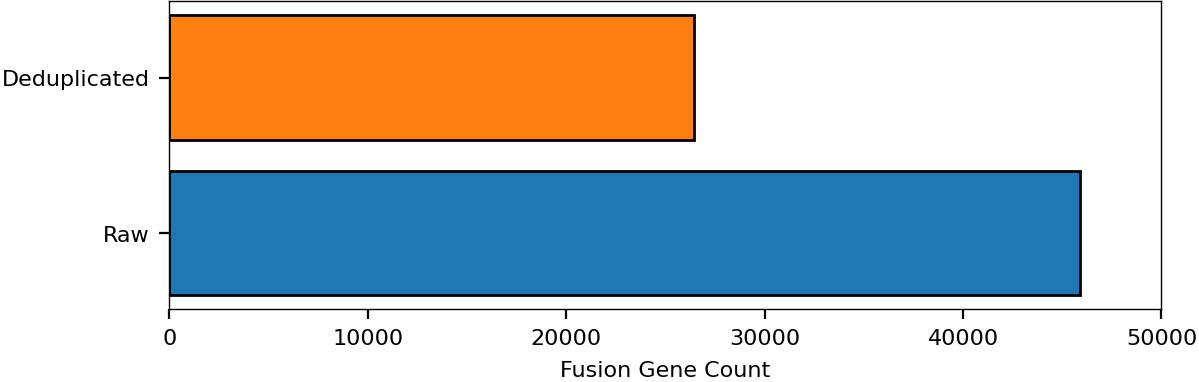

In [20]:
plt.barh(['Raw', 'Deduplicated'],[len(chimer_filt), len(collapsed_chimer)], color = ['tab:blue','tab:orange'], edgecolor = 'k', linewidth = 1)
plt.gcf().set_figheight(2)
plt.xlabel('Fusion Gene Count', size = 8)
plt.xticks(np.arange(0,60000,10000))
plt.show()

# Updated Analysis

Now that we have addressed the issue with the ChimerDB and have verified everything is working as intended will be running the analysis using the fully updated reference files and methods.

In [21]:
# Importing the full proteome n-gram analysis
ref_df = dansy.import_proteome_files(ref_file_dir='data/Current_Human_Proteome',
                                       ref_file_suffix='2026_0108.csv')
proteome_net = dansy.dansy(ref=ref_df, n=15)

# Getting the full set of naturally occuring n-grams to pass on to the fusion gene analysis
nat_ngrams_ids = set(proteome_net.ngrams).union(proteome_net.collapsed_ngrams)
interpro_dict = proteome_net.interpro_conversion

# Generate the network for the original canonical human proteome
G = proteome_net.G

# Get a couple of key parameters that can potentially change
cc_orig = nx.number_connected_components(G)
isol_orig = nx.number_of_isolates(G)
artic_orig = len(list(nx.articulation_points(G)))

proteome_gross_topo = [cc_orig, isol_orig, artic_orig]
ref_data = [ref_df, proteome_net.adj, proteome_net.collapsed_ngrams, interpro_dict, proteome_gross_topo]

Starting to fetch n-grams.
Finished getting all n-grams
Starting to generate adjacency
Finished building adjacency.


In [114]:
# Now let's see what happens when I run the analysis on this collapsed nonredundant chimer database
fusion_categories, pts,gc = fusionGeneAnalysis.perform_fusion_analysis(collapsed_chimer, cancersOI,gene_ID_conv_clean,ref_data, version=2, dansy_obj=proteome_net)

Generating reference network
Retrieving Ensembl IDs of interest
Adding exon and peptide information
There were 998 fusion(s) dropped from further analysis due to missing gene information
There were 533 fusions that the gene name had to be changed to upppercase
There were 792 patient(s) had a mismatch of strand information
There were 571 fusions with a UTR region as part of the fusion.
Due to missing uniprot information 3 fusion(s) were removed
There were 0 fusions that were removed due to domain annotations.
Reduced the network change calculation to 5850 unique architectures from 25421.
Determining changes in the fusion network


100%|██████████| 5850/5850 [00:13<00:00, 421.29it/s]


There were 2338 architecture(s) skipped due to presence in the original adjacency matrix.
Simple Gross Network Summary Generation


In [53]:
fusion_categories2, pts2,gc2 = fusionGeneAnalysis.perform_fusion_analysis(collapsed_chimer, cancersOI,gene_ID_conv_clean,ref_data, version=2, dansy_obj=proteome_net,expanded_flag=True)

Generating reference network
Retrieving Ensembl IDs of interest
Adding exon and peptide information
There were 998 fusion(s) dropped from further analysis due to missing gene information
There were 533 fusions that the gene name had to be changed to upppercase
There were 792 patient(s) had a mismatch of strand information
There were 571 fusions with a UTR region as part of the fusion.
Due to missing uniprot information 3 fusion(s) were removed
There were 0 fusions that were removed due to domain annotations.
Reduced the network change calculation to 5850 unique architectures from 25421.
Determining changes in the fusion network


100%|██████████| 5850/5850 [00:20<00:00, 291.32it/s]


There were 2338 architecture(s) skipped due to presence in the original adjacency matrix.
Simple Gross Network Summary Generation


In [54]:
post_change_summary = pd.DataFrame(index=cancersOI, columns=fusion_categories2['BLCA'].keys())

for can,can_details in fusion_categories2.items():
    for cat, cat_details in can_details.items():
        post_change_summary.loc[can,cat] = len(set(cat_details['Pt Members']))
        

In [55]:
post_change_summary

,No Change,Interconnectedness,Connect Components,Empty Domain,Reintroduction
GBM,453,33,32,216,92
LAML,36,20,47,45,27
PAAD,79,13,6,59,25
LUAD,575,89,66,492,144
PRAD,1474,80,70,497,129
OV,1046,143,70,1004,224
THCA,76,39,35,21,16
LGG,353,51,45,233,46
LUSC,652,89,99,516,159
BRCA,2298,338,253,1686,569


In [56]:
data = pd.melt(post_change_summary,ignore_index=False, value_name='Count', var_name='Category')
data['Cancer'] = data.index

In [57]:
row_order = post_change_summary.sum(axis = 1).sort_values(ascending=False).index

In [58]:
# Normalizing really quick
norm_summary = post_change_summary.copy()
norm_summary = norm_summary.div(norm_summary.sum(axis=1),axis=0)

In [59]:
# Reordering the columns to put them in an order I prefer for visualization
norm_summary = norm_summary[['Connect Components', 'Interconnectedness','Reintroduction','No Change','Empty Domain']]

In [60]:
norm_summary = norm_summary.reindex(row_order)

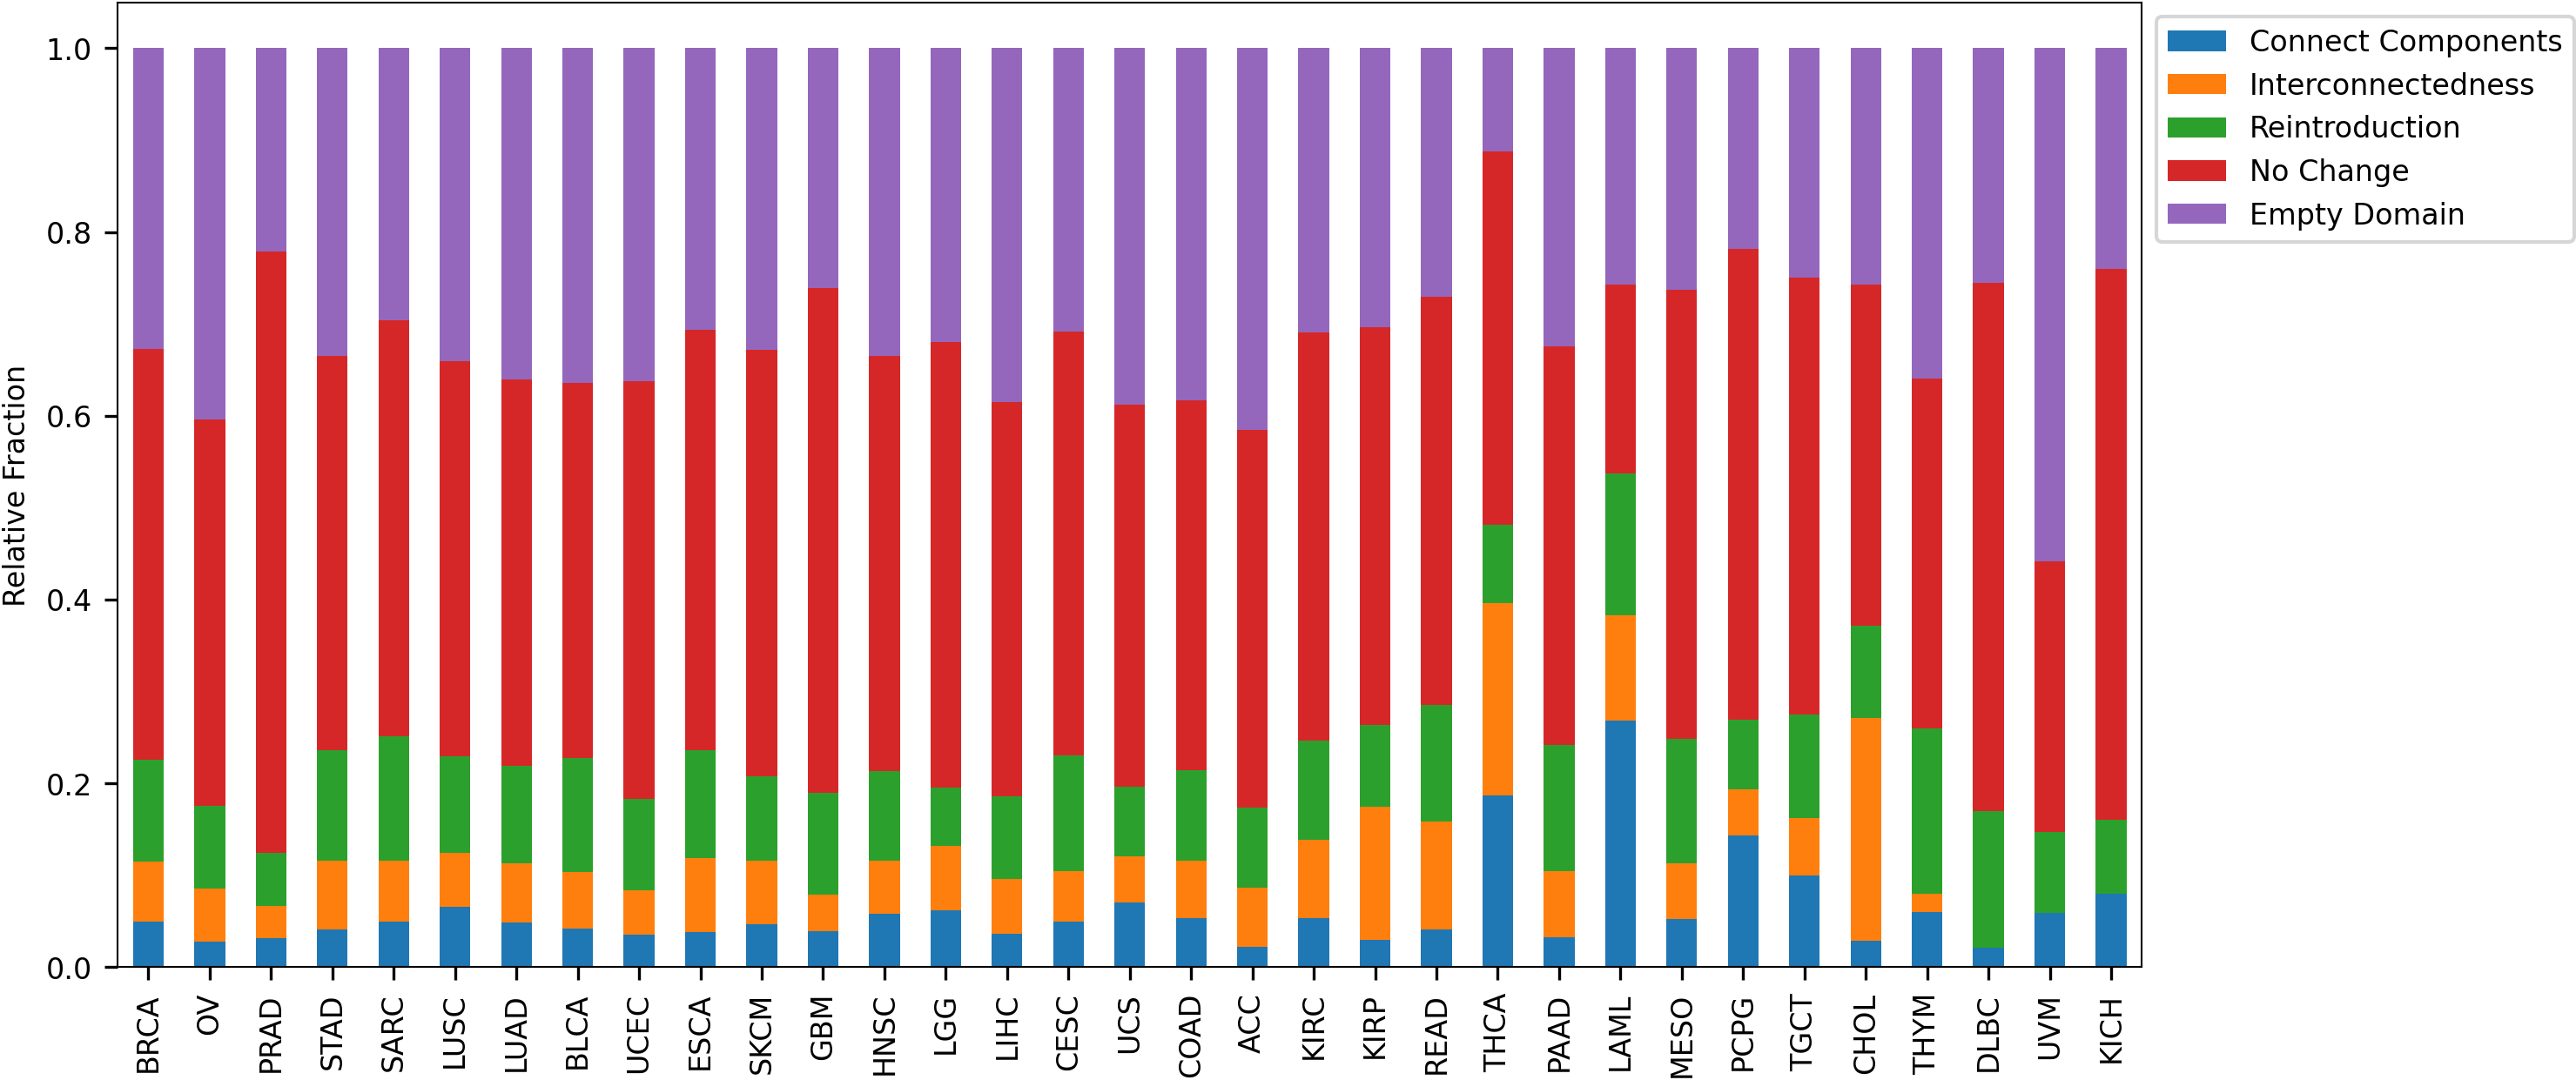

In [79]:
norm_summary.plot(kind='bar', stacked=True)
plt.gcf().set_dpi(300)
plt.legend(bbox_to_anchor = (1,1))
plt.ylabel('Relative Fraction', size = 8)
plt.gcf().set_figwidth(10)

In [62]:
fusion_counts = post_change_summary.sum(axis=1).sort_values(ascending=False).astype(int)

In [107]:
fusion_counts

BRCA    5144
OV      2487
PRAD    2250
STAD    1985
SARC    1600
LUSC    1515
LUAD    1366
BLCA    1255
UCEC    1123
ESCA    1061
SKCM    1044
GBM      826
HNSC     759
LGG      728
LIHC     688
CESC     486
UCS      397
COAD     355
ACC      231
KIRC     223
KIRP     201
READ     196
THCA     187
PAAD     182
LAML     175
MESO     133
PCPG     119
TGCT      80
CHOL      70
THYM      50
DLBC      47
UVM       34
KICH      25
dtype: int64

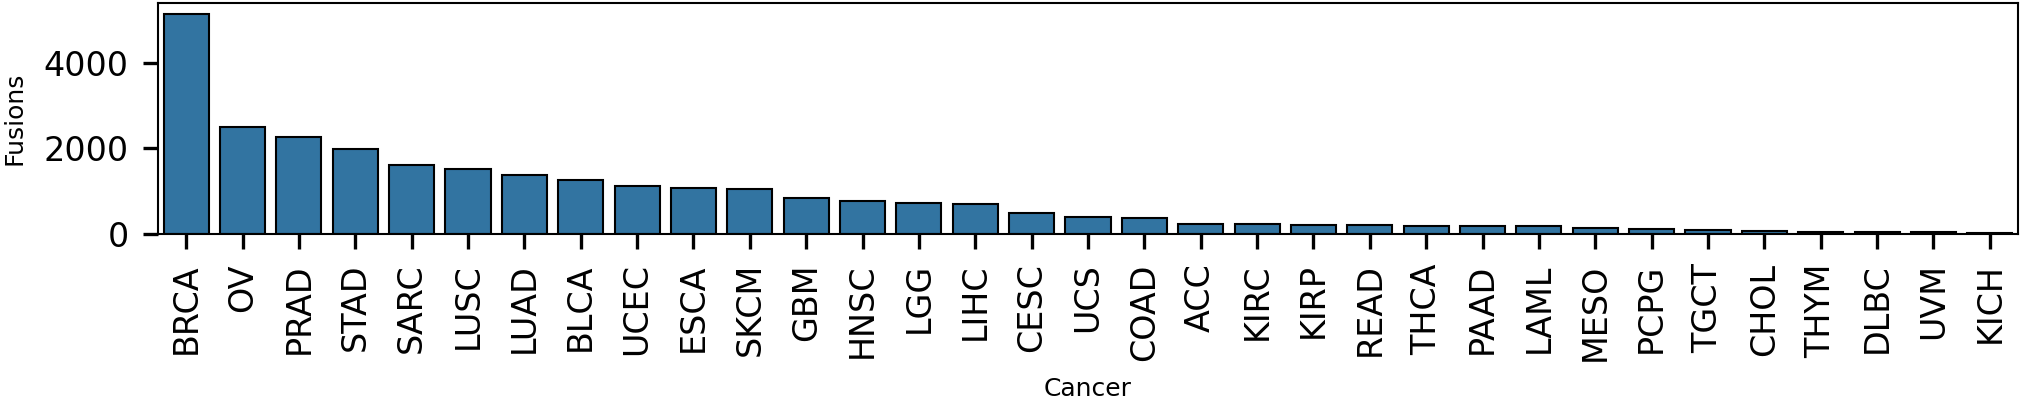

In [80]:
fcounts = pd.DataFrame(fusion_counts)
fcounts['Cancer'] = fcounts.index
fcounts.rename(columns={0:'Fusions'},inplace=True)
sns.barplot(fcounts, y = 'Fusions', x = 'Cancer', edgecolor = 'k', linewidth = 0.5)
plt.gcf().set_dpi(300)
plt.xticks(rotation = 90)
plt.gcf().set_figwidth(8)
plt.gcf().set_figheight(1)



Now as a quick analysis let me check the number of unique architectures relative to the number of unique fusion pairs

In [108]:
temp_innter = []
for can in cancersOI:
    for cat, cat_details in fusion_categories2[can].items():
        
        al = len(cat_details['Unique Architectures'])
        x = set()
        for p in cat_details['Pt Members']:
            x.update([pts2[p]['Fusion Protein']])
        fl = len(x)
        pl = len(set(cat_details['Pt Members']))
        temp_innter.append((can,cat,al,fl,pl))

In [109]:
num_summary = pd.DataFrame.from_records(temp_innter, columns=['Cancer','Category','Architectures','Fusions','Total'])

In [110]:
num_summary['Ratio'] = num_summary['Fusions']/num_summary['Total']

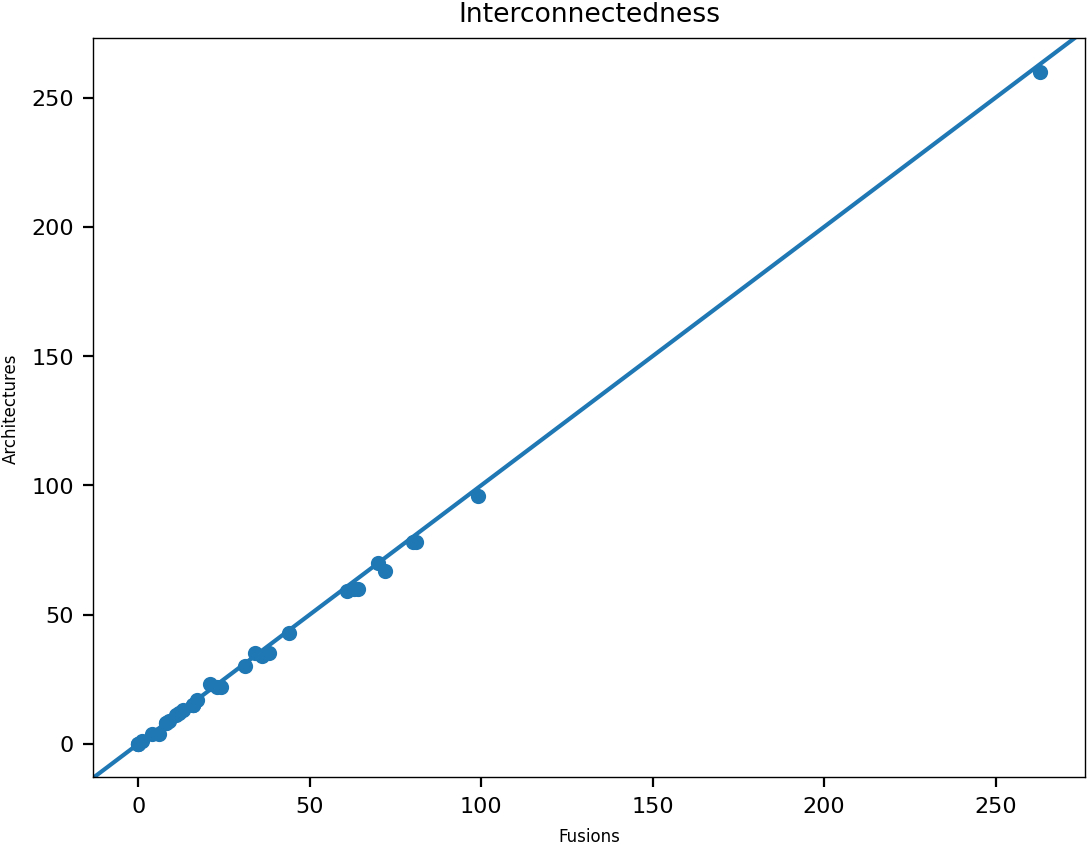

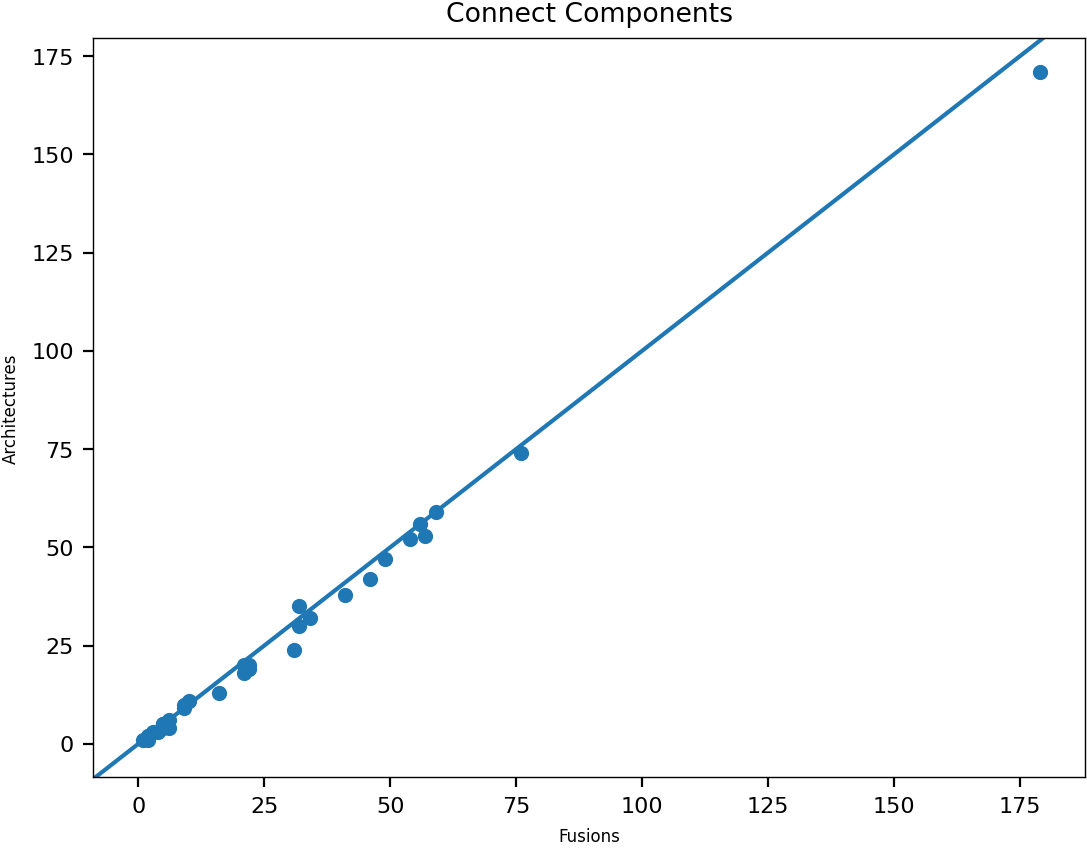

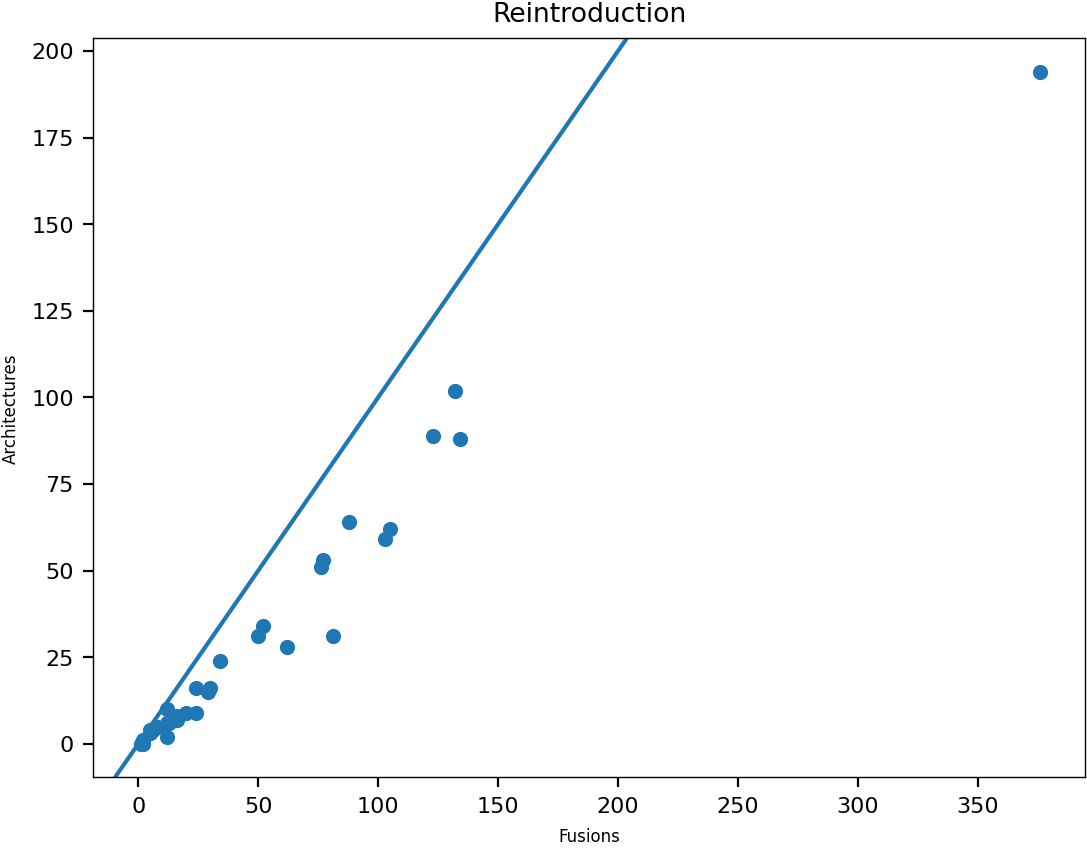

In [111]:
for cat in num_summary['Category'].unique():
    if cat not in ['Empty Domain', 'No Change']:
        num_summary[num_summary['Category'].isin([cat])].plot.scatter(x = 'Fusions', y = 'Architectures')
        plt.axline((0,0),slope=1)
        plt.title(cat)

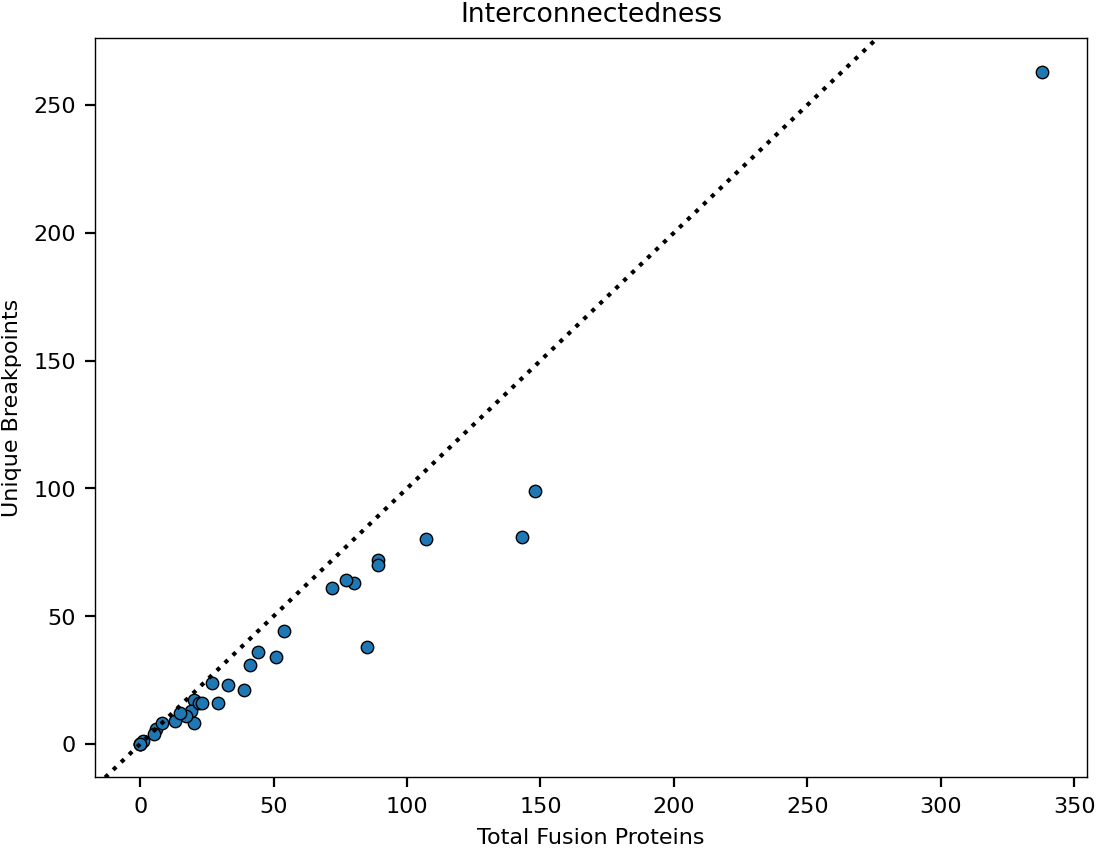

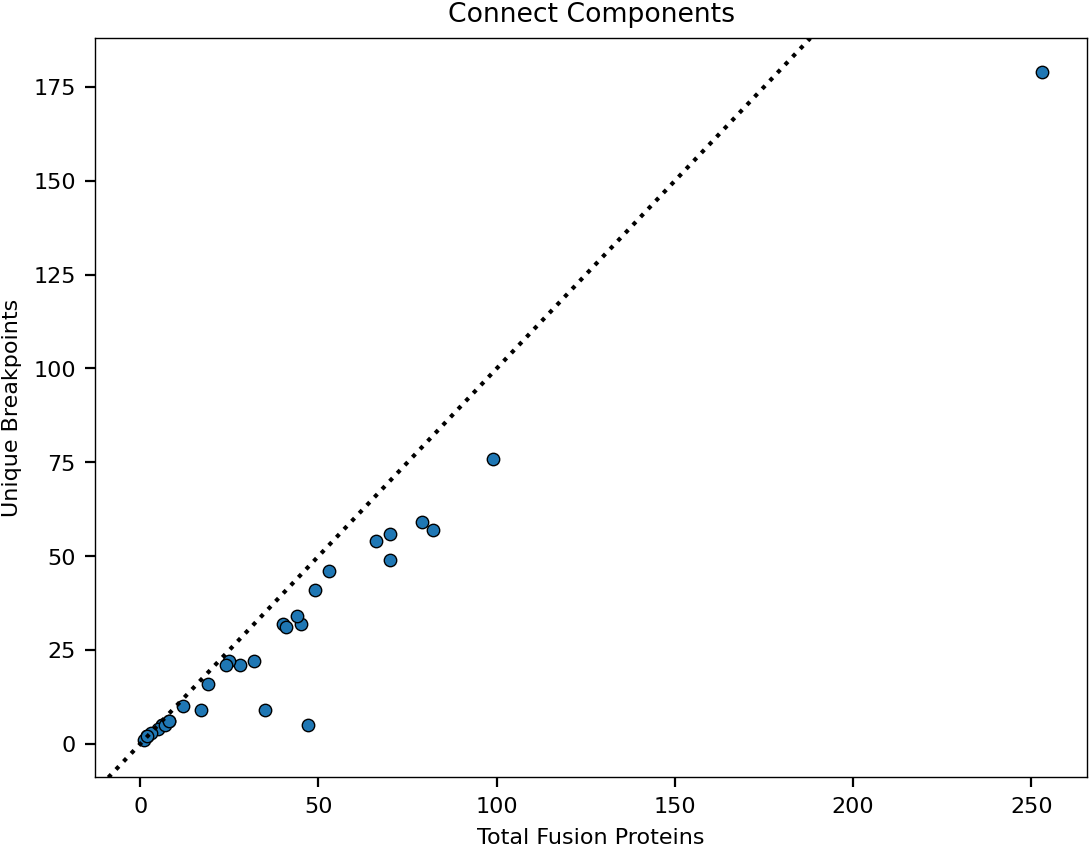

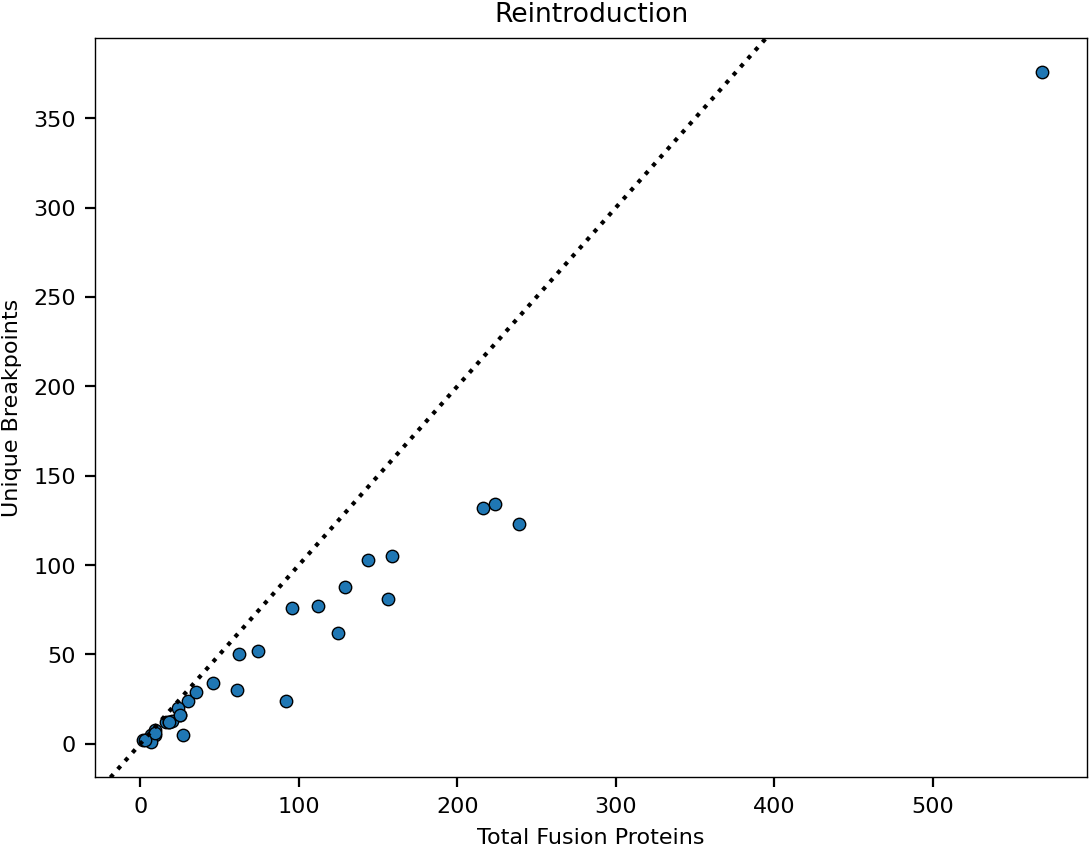

In [ ]:
for cat in num_summary['Category'].unique():
    if cat not in ['Empty Domain', 'No Change']:
        num_summary[num_summary['Category'].isin([cat])].plot.scatter(x = 'Total', y = 'Fusions', edgecolor = 'k', s = 20, linewidth = 0.5)
        plt.axline((0,0),slope=1, ls = ':', color = 'k')
        plt.title(cat)
        plt.xlabel('Unique Breakpoints', size = 8)
        plt.ylabel('Total Fusion Proteins', size = 8)

In [120]:
num_summary[(num_summary['Category'].isin(['Connect Components']))]

,Cancer,Category,Architectures,Fusions,Total,Ratio
2,GBM,Connect Components,20,22,32,0.687500
7,LAML,Connect Components,5,5,47,0.106383
12,PAAD,Connect Components,5,5,6,0.833333
17,LUAD,Connect Components,52,54,66,0.818182
22,PRAD,Connect Components,56,56,70,0.800000
27,OV,Connect Components,47,49,70,0.700000
32,THCA,Connect Components,9,9,35,0.257143
37,LGG,Connect Components,35,32,45,0.711111
42,LUSC,Connect Components,74,76,99,0.767677
47,BRCA,Connect Components,171,179,253,0.707510


## Now checking which fusions are contributing the most to the categories identified for either PRAD, THCA, or LAML.

## Attempting some expression based analysis.

Based on the above there are 2 potential cancers that are of interest to further look at with expression and survival because of how few unique fusions there are relative to patient number. Additionally, there are 2 potential cancers that can act as proxies for the others which have unique domain architectures for almost every fusion, but have sufficient numbers:
1. THCA (Thyroid Carcinoma)
2. LAML (Acute lymphoid leukemia)
3. OV (Ovarian)
4. STAD (Stomach Adenocarcinoma)

However, I will also be considering the PRAD cohort because it is somewhat unique where it is fairly different from the rest by having a large fraction of No Change fusions/patients (due to the TMPRSS2-ERG fusion). I will also consider the LUAD cohort because it has one fusion EML4-ALK that is fairly well known, but not shown frequently here and could act as a proxy for the other cancers instead of the OV or STAD cohorts.

Before moving on to doing some expression and clinical analysis, I am now going to look at some of the other broad characteristics of the fusions that were analyzed (e.g. what type of fusion such as CDS-CDS or 3' UTR-CDS and oncogene, kinase, etc characteristics).

In [137]:
# First starting with the broad categories
analyzed_chimer = collapsed_chimer.filter(gc2.index, axis = 0)
fusion_dansy_summary = gc2.copy()
idx_cat_conv = {}
idx_can_conv = {}
for can, can_details in fusion_categories2.items():
    for cat, cat_details in can_details.items():
        idx_OI = set(cat_details['Pt Members'])
        for i in idx_OI:
            idx_cat_conv[i] = cat
            idx_can_conv[i] = can

fusion_dansy_summary['Category'] = fusion_dansy_summary.index.map(idx_cat_conv)
fusion_dansy_summary['Cancer'] = fusion_dansy_summary.index.map(idx_can_conv)

In [138]:
analyzed_chimer['Kinase_involved'] = (~analyzed_chimer['H_kinase'].isna()) | (~analyzed_chimer['T_kinase'].isna())
analyzed_chimer['TF_involved'] = (~analyzed_chimer['H_transcription_factor'].isna()) | (~analyzed_chimer['T_transcription_factor'].isna())
analyzed_chimer['TS_involved'] = (~analyzed_chimer['H_tumor_suppressor'].isna()) | (~analyzed_chimer['T_tumor_suppressor'].isna())
analyzed_chimer['Oncogene_involved'] = (~analyzed_chimer['H_oncogene'].isna()) | (~analyzed_chimer['T_oncogene'].isna())

In [139]:
# Now combining the two dataframes to make a single large summary dataframe that will be used for plotting purposes.

# Defining columns of interest for the merge since we don't need the full ChimerDB information just some quick categories
colsOI = ['Chr_info', 'Frame','Kinase_involved','TF_involved','TS_involved','Oncogene_involved','Fusion_pair','Source', 'BarcodeID']
fusion_dansy_summary = fusion_dansy_summary.merge(analyzed_chimer.filter(colsOI, axis=1), left_index=True, right_index=True)

# Need to fix the Frame variables a little bit because there are at least 2 categories due to abbreviation/capitalization
fusion_dansy_summary['Frame'] = fusion_dansy_summary['Frame'].str.upper().str.replace('\'','')
fusion_dansy_summary['PatientID'] = fusion_dansy_summary['BarcodeID'].apply(check_tcga_id)

In [140]:
fusion_dansy_summary.to_csv('260203_Individual_Fusion_Summary_info.csv')

In [141]:
def get_category_summary(var, data=fusion_dansy_summary):
    temp = data.groupby(['Cancer','Category'])[var].value_counts().unstack().fillna(0)
    temp = temp.transform(lambda x: x/temp.sum(axis=1)).reset_index()
    dataOI = temp.melt(id_vars=['Cancer', 'Category'])

    return dataOI

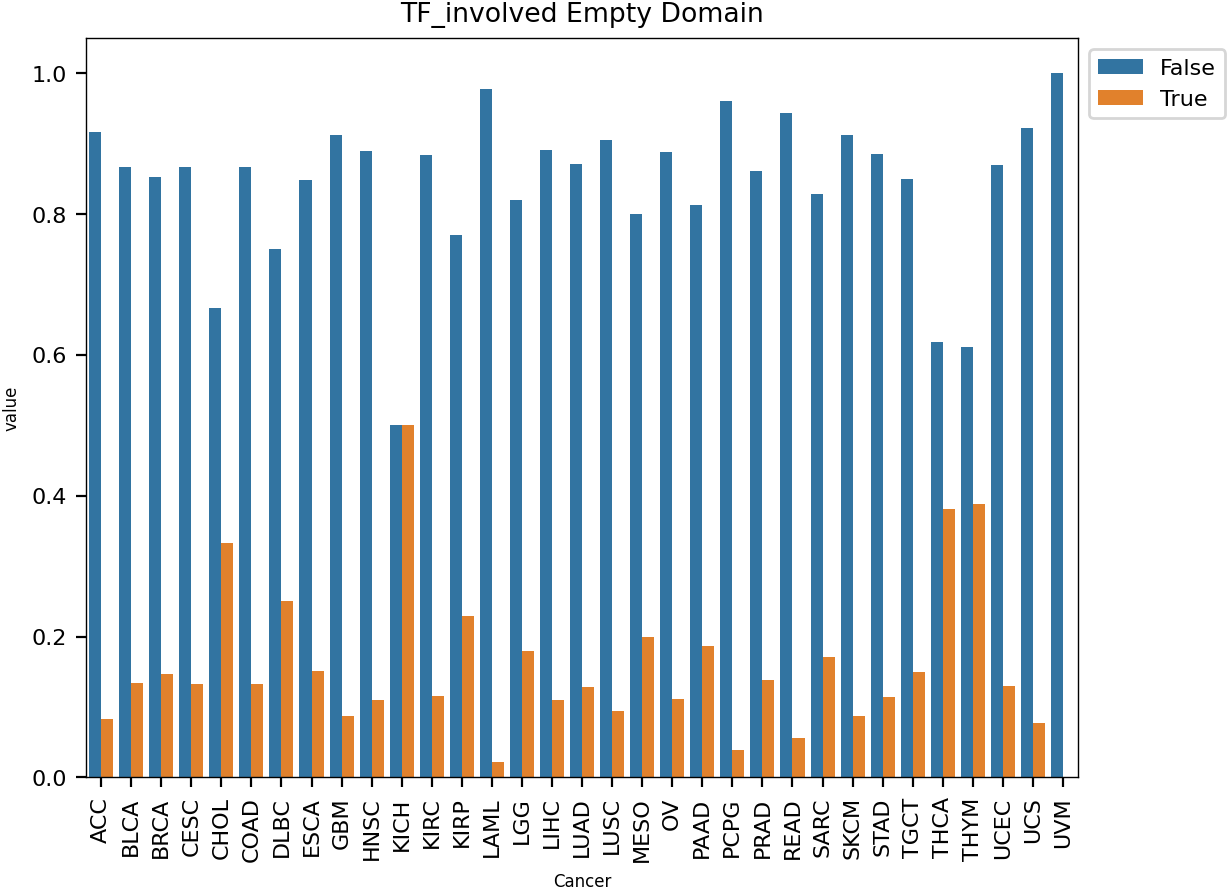

In [142]:
catOI = 'TF_involved'
fuscat = 'Empty Domain'
dataOI = get_category_summary(var = catOI)

sns.barplot(dataOI[dataOI['Category'] == fuscat], x = 'Cancer',hue=catOI,y = 'value')
plt.xticks(rotation=90)
plt.title(' '.join([catOI,fuscat]))
plt.legend(bbox_to_anchor = (1,1))
plt.show()

In [143]:
# This is an attempt to get a simpler summary graphic for the fusions across the cancer types for the binary variables
colsOI = ['Kinase_involved','TF_involved','TS_involved','Oncogene_involved']
pos_frac_sum = pd.DataFrame()
for cat in colsOI:
    temp_data = get_category_summary(cat)
    if len(pos_frac_sum) < 1:
        pos_frac_sum = temp_data[temp_data[cat] == True].copy()
    else:
        pos_frac_sum = pos_frac_sum.merge(temp_data[temp_data[cat] == True].copy(),on = ['Cancer','Category'])
    pos_frac_sum.drop(cat,axis =1, inplace=True)
    pos_frac_sum.rename(columns={'value':cat}, inplace=True)

full_frac = pd.DataFrame()
for cat in colsOI:
    temp = fusion_dansy_summary.groupby(['Cancer'])[cat].value_counts().unstack().fillna(0)
    temp = temp.transform(lambda x: x/temp.sum(axis=1)).reset_index().melt(id_vars='Cancer')
    if len(full_frac) < 1:
        full_frac = temp[temp[cat] == True].copy()
    else:
        full_frac = full_frac.merge(temp[temp[cat] == True].copy(),on = ['Cancer'])
    full_frac.drop(cat, axis=1, inplace=True)
    full_frac.rename(columns={'value':cat}, inplace=True)



In [160]:
dataOI

,Kinase_involved,TF_involved,TS_involved,Oncogene_involved
Cancer,,,,
ACC,0.027523,0.119266,0.133028,0.073394
BLCA,0.031414,0.150960,0.173647,0.125654
BRCA,0.048765,0.157502,0.160614,0.131148
CESC,0.052632,0.141876,0.185355,0.173913
COAD,0.029674,0.181009,0.169139,0.127596
ESCA,0.057692,0.153846,0.178138,0.134615
GBM,0.089214,0.089214,0.159787,0.143808
HNSC,0.049793,0.121715,0.174274,0.116183
KIRC,0.014423,0.192308,0.182692,0.129808


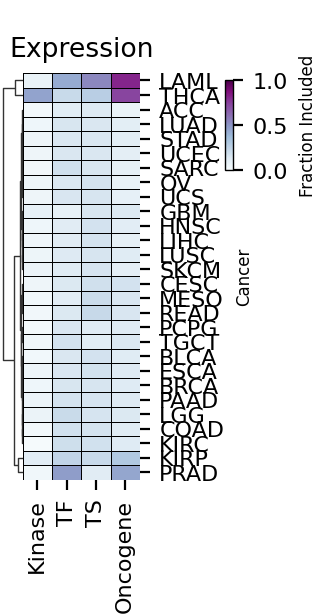

In [163]:
large_cohorts = fusion_counts[fusion_counts >= 75].index.tolist()
dataOI = full_frac[(full_frac['Cancer'].isin(large_cohorts))].copy()
dataOI.rename(columns={'Kinase_involved':'Kinase','TF_involved':'TF','TS_involved':'TS','Oncogene_involved':'Oncogene' },inplace=True)
dataOI.set_index('Cancer', inplace=True)
p = sns.clustermap(dataOI,yticklabels=True, cmap='BuPu', linecolor = 'k', linewidths=0.25,dendrogram_ratio=0.15,
                cbar_kws={'label':'Fraction Included'},
                method='ward',
                col_cluster=False,
                vmin =0,vmax=1
                )
cx0,cy0,cw,ch = p.cbar_pos
p.ax_cbar.set_position([1.5,0.65,cw,ch])
cax = p.figure.get_children()[-1]
cax.spines['outline'].set_color('k')
cax.spines['outline'].set_linewidth(0.5)

plt.gcf().set_size_inches(0.75,2.5)
p.ax_heatmap.set_xticklabels(p.ax_heatmap.get_xticklabels(), rotation=90)
p.ax_heatmap.set_yticklabels(p.ax_heatmap.get_yticklabels(), rotation=0)
p.ax_heatmap.set_title('Expression')
plt.show()

,Cancer,Category,Kinase_involved,TF_involved,TS_involved,Oncogene_involved
0,ACC,Connect Components,0.000000,0.200000,0.200000,0.200000
1,ACC,Empty Domain,0.041667,0.083333,0.114583,0.052083
2,ACC,Interconnectedness,0.066667,0.200000,0.000000,0.066667
3,ACC,No Change,0.012195,0.097561,0.158537,0.085366
4,ACC,Reintroduction,0.000000,0.300000,0.200000,0.100000
...,...,...,...,...,...,...
157,UCS,Reintroduction,0.000000,0.233333,0.300000,0.133333
158,UVM,Connect Components,0.500000,0.000000,0.000000,0.500000
159,UVM,Empty Domain,0.105263,0.000000,0.000000,0.000000
160,UVM,No Change,0.285714,0.428571,0.000000,0.142857


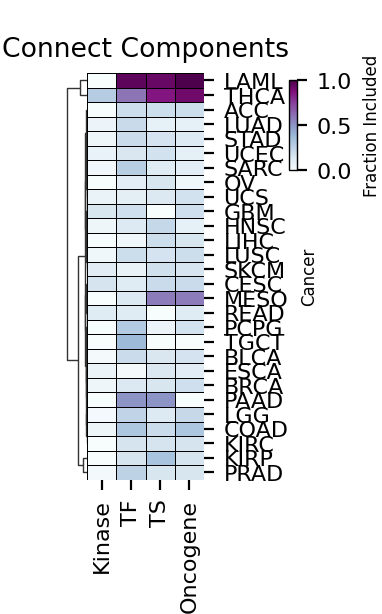

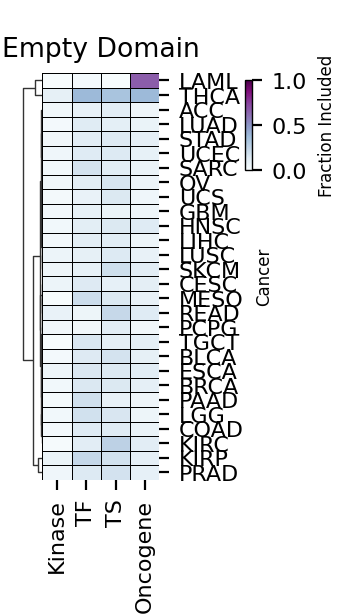

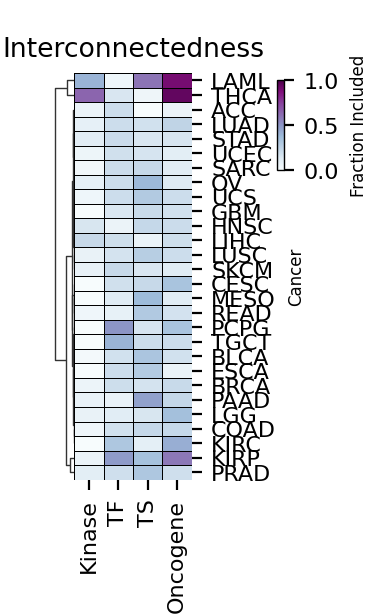

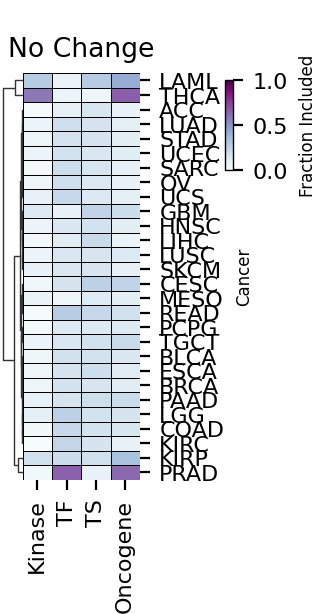

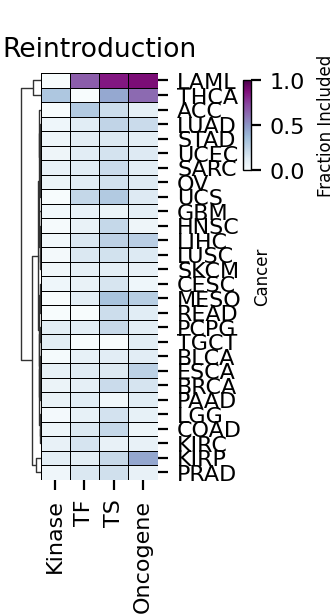

In [167]:
# Now plotting it via the a heatmap
r_order = p.dendrogram_row.linkage
# As part of the visual I will limit it to only cancers with >50 patients with fusions to limit influences from outliers
large_cohorts = fusion_counts[fusion_counts >= 75].index.tolist()
pos_frac_sum.rename(columns={'Kinase_involved':'Kinase','TF_involved':'TF','TS_involved':'TS','Oncogene_involved':'Oncogene' },inplace=True)
for fuscat in pos_frac_sum.Category.unique():
    dataOI = pos_frac_sum[(pos_frac_sum['Category'] == fuscat) & (pos_frac_sum['Cancer'].isin(large_cohorts))].copy()
    dataOI.drop('Category',axis = 1, inplace=True)
    dataOI.set_index('Cancer', inplace=True)
    p = sns.clustermap(dataOI,yticklabels=True, cmap='BuPu', linecolor = 'k', linewidths=0.25,dendrogram_ratio=0.15,
                    cbar_kws={'label':'Fraction Included'},
                    method='ward',
                    col_cluster=False,
                    vmin =0,vmax=1,
                    row_linkage = r_order
                    )
    cx0,cy0,cw,ch = p.cbar_pos
    p.ax_cbar.set_position([1.5,0.65,cw,ch])
    cax = p.figure.get_children()[-1]
    cax.spines['outline'].set_color('k')
    cax.spines['outline'].set_linewidth(0.5)

    plt.gcf().set_size_inches(0.75,2.5)
    p.ax_heatmap.set_xticklabels(p.ax_heatmap.get_xticklabels(), rotation=90)
    p.ax_heatmap.set_yticklabels(p.ax_heatmap.get_yticklabels(), rotation=0)
    p.ax_heatmap.set_title(fuscat)
    plt.show()

Similar to above which looks at the relative fraction of different categories of fusion partners, here I will look at the frame for each and for each category provide an overview heatmap

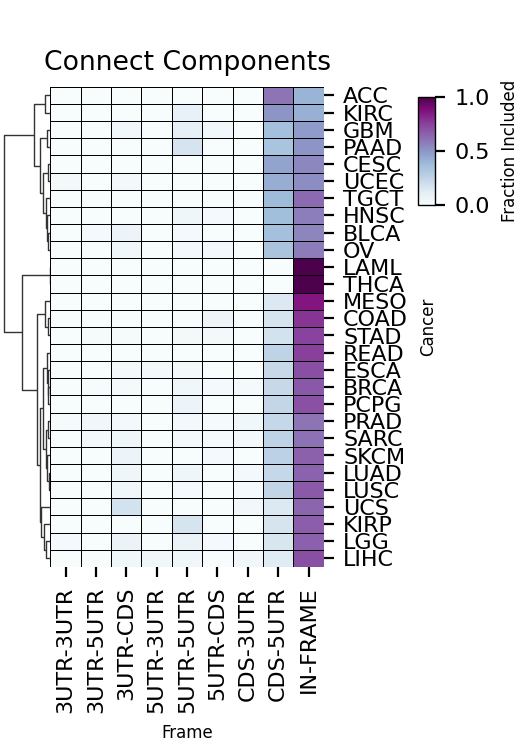

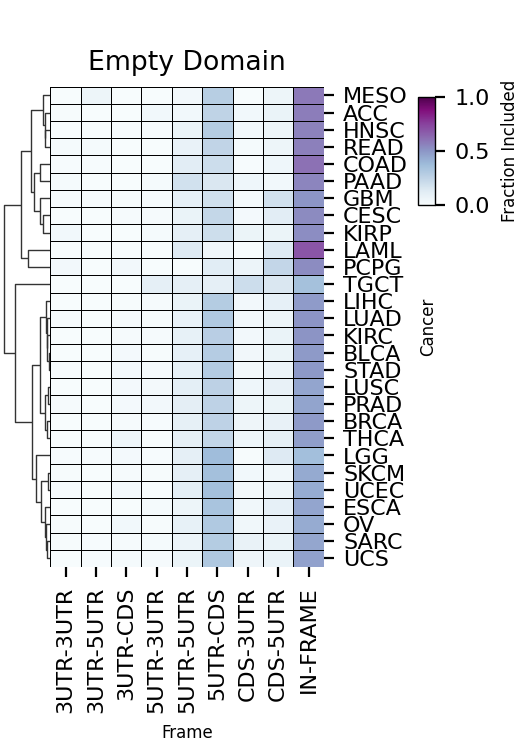

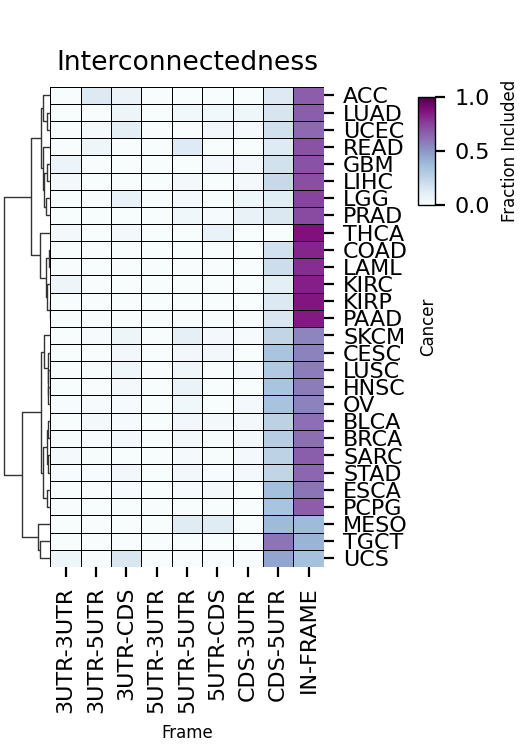

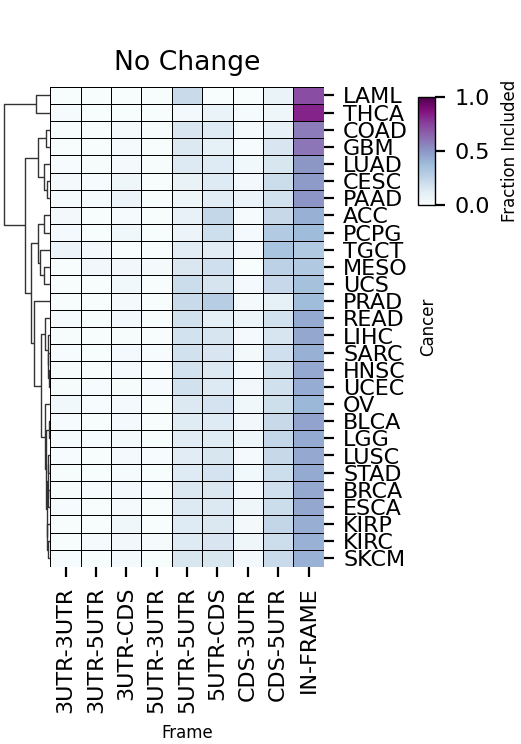

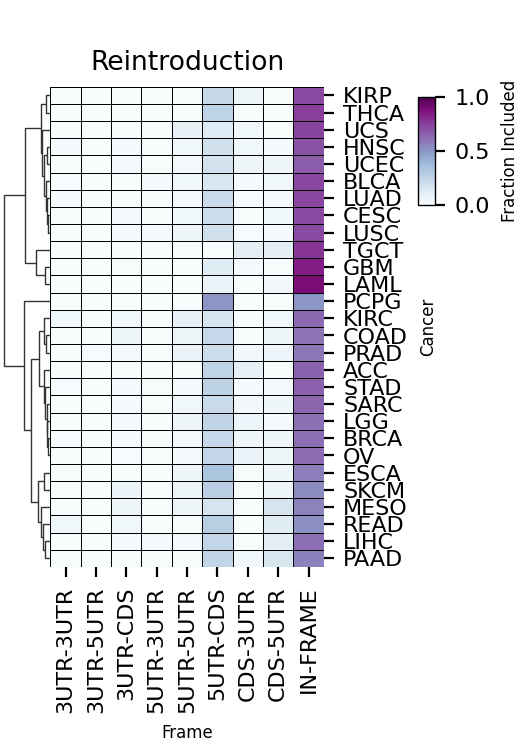

In [45]:
catOI = 'Frame'
fuscat = 'Connect Components'
temp = fusion_dansy_summary.groupby(['Cancer','Category'])[catOI].value_counts().unstack().fillna(0)
temp = temp.transform(lambda x: x/temp.sum(axis=1)).reset_index()
dataOI = temp.melt(id_vars=['Cancer', 'Category'])

for fuscat in dataOI.Category.unique():
    plotData = dataOI[(dataOI['Category'] == fuscat) & (dataOI['Cancer'].isin(large_cohorts))].copy()
    plotData = plotData.pivot(columns='Frame', index=['Cancer','Category'], values='value').reset_index()
    plotData.drop('Category',axis = 1, inplace=True)
    plotData.set_index('Cancer', inplace=True)
    p = sns.clustermap(plotData,yticklabels=True, cmap='BuPu', linecolor = 'k', linewidths=0.25,dendrogram_ratio=0.15,
                    cbar_kws={'label':'Fraction Included'},
                                        method='ward',
                    col_cluster=False,
                    vmin =0,vmax=1
                    )
    cx0,cy0,cw,ch = p.cbar_pos
    p.ax_cbar.set_position([1.2,0.65,cw,ch])
    cax = p.figure.get_children()[-1]
    cax.spines['outline'].set_color('k')
    cax.spines['outline'].set_linewidth(0.5)

    plt.gcf().set_size_inches(1.75,3)
    p.ax_heatmap.set_xticklabels(p.ax_heatmap.get_xticklabels(), rotation=90)
    p.ax_heatmap.set_yticklabels(p.ax_heatmap.get_yticklabels(), rotation=0)

    p.ax_heatmap.set_title(fuscat)
    plt.show()


In [128]:
# So now we need to get the TCGA patient IDs of these cancers to get the cohorts of interest.

# First getting the fusion IDs from ChimerDB to get the fusions
cancers_for_analysis = ['THCA', 'LAML','OV','PRAD','PAAD','LUAD']

can_idx = {}
for can in cancers_for_analysis:
    inner_pts = set()
    for cat, cat_details in fusion_categories2[can].items():
        inner_pts.update(cat_details['Pt Members'])
    can_idx[can] = inner_pts

# Now get the BarcodeIDs
can_pts = {}
for can,fusion_idx in can_idx.items():
    x = collapsed_chimer['BarcodeID'].filter(fusion_idx)
    can_pts[can] = x.apply(check_tcga_id).unique()


In [129]:
# Now let's import the clinical data to get an idea of how many patient's transcript results we will be fetching

# As just a double check now getting each cancer's patient cohort and double-checking that each patient with a fusion is actually present.
tcga_ptsOI = {}
for can in cancers_for_analysis:
    fusion_pts = can_pts[can]
    if can == 'LAML':
        sep = '\t'
        ext = '.tsv'
        column = 'cases.submitter_id'
    else:
        sep = ','
        ext = '.csv'
        column = 'submitter_id'
    clinical_info = pd.read_csv(f'TCGA_Expression_Analysis/TCGA-{can}_clinical{ext}',sep=sep)
    full_pt_list = clinical_info[column].unique()
    x = set(fusion_pts).difference(full_pt_list)
    if x:
        raise ValueError('There are patients with fusions that are not part of the TCGA cohort.')
    

    y = set(full_pt_list).difference(fusion_pts)
    print(f'For {can} there are a total of {len(full_pt_list)} with {len(y)} having no fusions in ChimerDB.')
    if len(full_pt_list)-len(y) != len(fusion_pts):
        raise ValueError('There are fewer patients with fusions than expected.')

    tcga_ptsOI[can] = full_pt_list

For THCA there are a total of 507 with 406 having no fusions in ChimerDB.
For LAML there are a total of 200 with 144 having no fusions in ChimerDB.
For OV there are a total of 608 with 233 having no fusions in ChimerDB.
For PRAD there are a total of 500 with 105 having no fusions in ChimerDB.
For PAAD there are a total of 185 with 112 having no fusions in ChimerDB.
For LUAD there are a total of 585 with 246 having no fusions in ChimerDB.


Now that we verified that all the fusion patients are available in the clinical information for potential survival information. This will then be expanded to see how the expression of some of the fusion partners compare to non-fusion patients.

In [130]:
prots = set()
gene_pairs = set()
can_genes = set()
fusionOI = 'CCDC6-RET'
canOI = 'THCA'
pflag = False
for idx in can_idx[canOI]:
    prots.add(pts2[idx]['Fusion Protein'])
    if pts2[idx]['Fusion Protein'] == fusionOI and pflag == False:
        genesOI = [i for i in pts2[idx]['Genes']]
        pflag = True
    s = '-'.join([i for i in pts2[idx]['Genes']])
    can_genes.update([i for i in pts2[idx]['Genes']])
    gene_pairs.add(s)

In [131]:
fv_genes = [k.split('-')[0] for k in prots]
thr_genes = [k.split('-')[1] for k in prots]

In [132]:
Counter(fv_genes)

Counter({'TMEM242': 1,
         'SND1': 1,
         'PAX8': 3,
         'IFT74': 1,
         'BCL2L11': 1,
         'FGFR2': 1,
         'SPSB1': 1,
         'TG': 1,
         'TRIM27': 1,
         'CACNA2D3': 1,
         'GTF2IRD1': 1,
         'NTRK3': 2,
         'TPM3': 1,
         'ZNF277': 1,
         'TFG': 2,
         'MACF1': 1,
         'RET': 2,
         'HMGB1': 1,
         'DLG5': 1,
         'BACE2': 1,
         'BRAF': 6,
         'INTS3': 1,
         'BCKDHA': 1,
         'CSGALNACT2': 1,
         'CPSF6': 1,
         'MET': 1,
         'CBX5': 1,
         'LLGL1': 1,
         'GAS8': 1,
         'TRA2A': 1,
         'NFIX': 1,
         'RBM28': 1,
         'WARS': 1,
         'MKRN1': 1,
         'PPARG': 1,
         'ZC3HAV1': 1,
         'CHD8': 1,
         'APC': 1,
         'ERRFI1': 1,
         'IQGAP1': 1,
         'CCDC6': 1,
         'LMBRD1': 1,
         'SOS1': 1,
         'AP3B1': 1,
         'VCL': 1,
         'TBC1D5': 1,
         'STRN': 1,
         'SQST

In [133]:
expr = pd.read_csv(f'TCGA_Expression_Analysis/TCGA-{canOI}_Expression.csv',index_col=0)
expr['gene_id'] = expr['gene_id'].apply(lambda x: x.split('.')[0])
exprOI = expr[expr['gene_id'].isin(can_genes)].copy()


In [134]:
# Now rename the columns so that they are limited to only the key portions of hte barcode
exprOI.rename(columns=check_tcga_id, inplace=True)

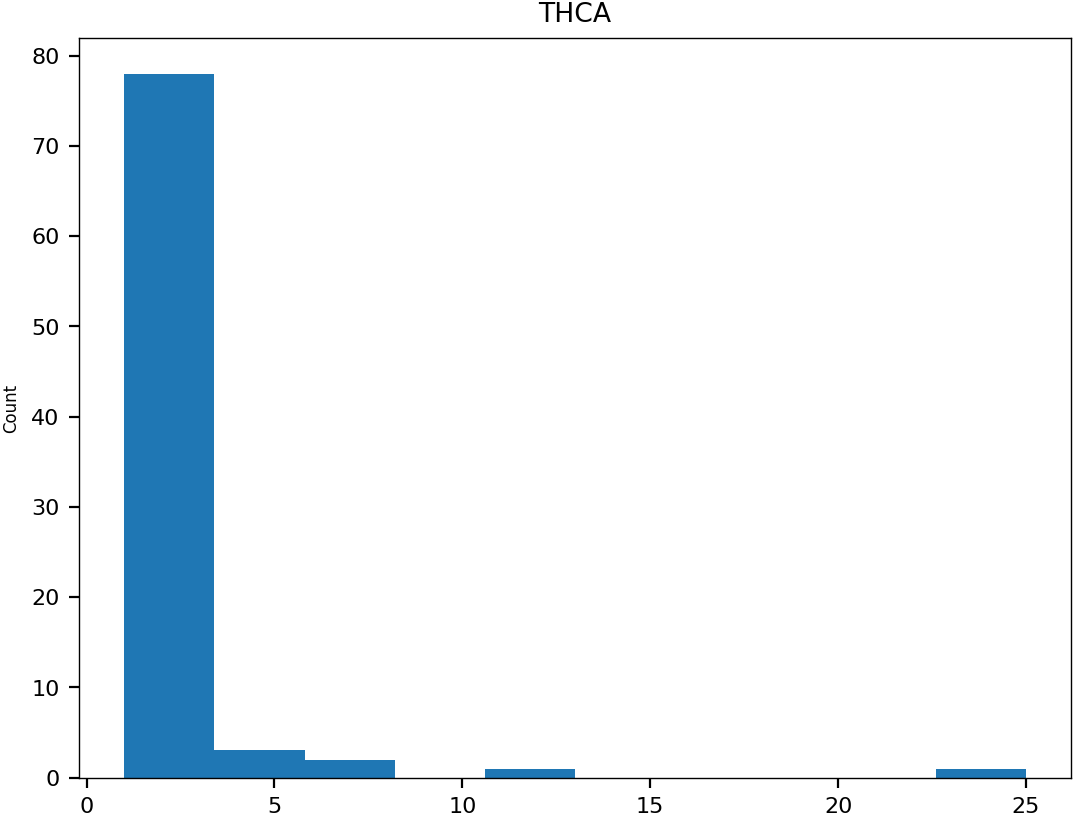

In [145]:
canOI = 'THCA'
plt.hist(Counter(fusion_dansy_summary[fusion_dansy_summary['Cancer'] == canOI].Fusion_pair).values())
plt.title(canOI)
plt.ylabel('Count')
plt.show()

In [146]:

x = fusion_dansy_summary[(fusion_dansy_summary['Fusion_pair'] == fusionOI) & (fusion_dansy_summary['Cancer'] == canOI)].BarcodeID.unique()
y = set([check_tcga_id(i) for i in x])

In [147]:
exprPlot = exprOI[exprOI['gene_id'].isin(genesOI)].melt(id_vars=['gene_id','gene_name'], var_name='BarcodeID',value_name='Count')
exprPlot['Fusion_presence'] = exprPlot['BarcodeID'].apply(lambda x: x in y)

Text(0.5, 1.0, 'THCA- CCDC6-RET Fusion')

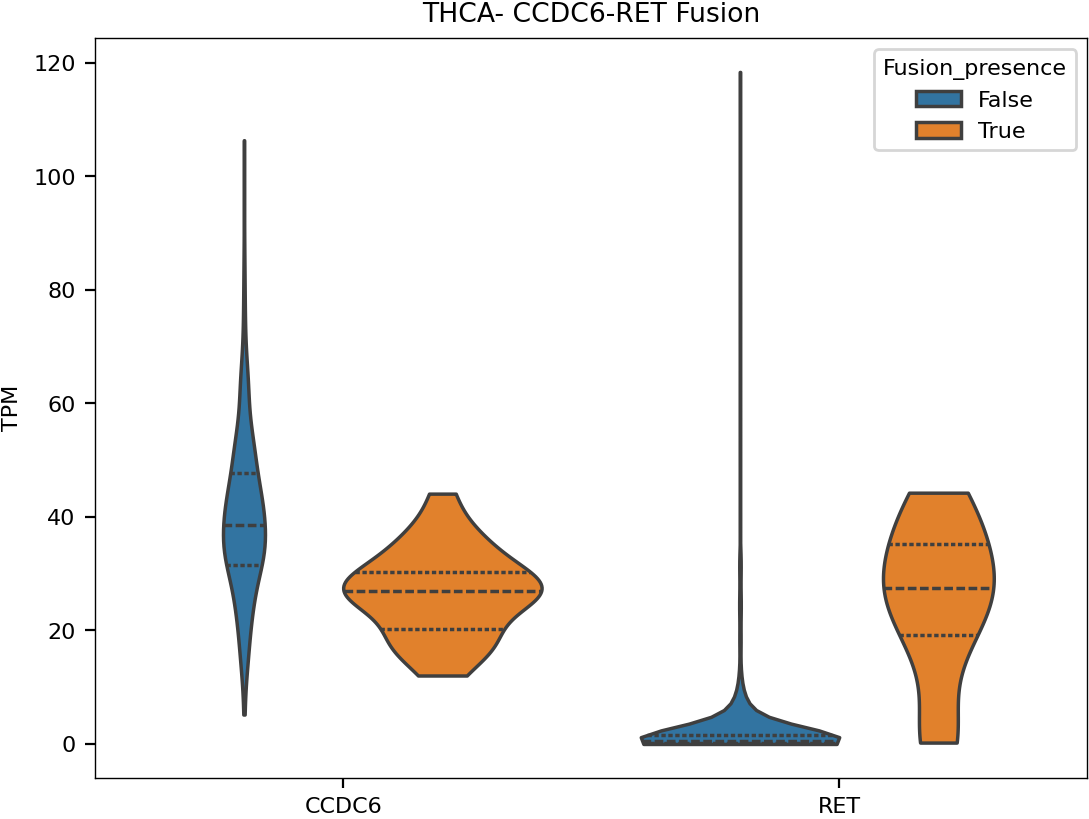

In [159]:
sns.violinplot(exprPlot, x = 'gene_name', hue='Fusion_presence', y = 'Count',dodge=True, inner='quart', cut = 0)
plt.ylabel('TPM', size = 8)
plt.xlabel(None)
plt.title('THCA- CCDC6-RET Fusion')

# Testing the class based version of the analysis.

To help with making this a little more flexible for other datasets I have created a class based version of the fusion workflow and am testing it below to ensure it is operating properly.

In [22]:
import fusionClasses as fusions
from tqdm import tqdm

In [155]:
import importlib
importlib.reload(fusions)


<module 'fusionClasses' from '/Users/yzv6ek/Documents/GitHub/Naegle Lab/DANSy_Applications/fusionClasses.py'>

In [9]:
strand_map = {'+':1,'-':-1}
fusions_list1 = []
for pt, details in tqdm(pts2.items()):
    varargs = {}
    n = details['Fusion Protein']
    genome_build = details['Genome Build']
    for g, g_info in details['Genes'].items():
        c = g_info['Chromosome']
        p = g_info['ChimerDB_Position']
        s = strand_map[g_info['Strand'].replace('\'','')]
        if g_info['Fusion pos'] == 5:
            x = 'h'
        else:
            x = 't'
        varargs[x+'_gene'] = g
        varargs[x+'_chr'] = c
        varargs[x+'_pos'] = p
        varargs[x+'_strand'] = s
    fusion_test = fusions.fusionGene(name = n, genome_build=genome_build, silent=True, **varargs, id = pt)
    fusions_list1.append(fusion_test)

NameError: name 'pts2' is not defined

In [85]:
collapsed_chimer.columns

Index(['id', 'ChimerDB_Type', 'Source', 'webSource', 'Fusion_pair', 'H_gene',
       'H_chr', 'H_position', 'H_strand', 'T_gene', 'T_chr', 'T_position',
       'T_strand', 'Genomic_breakpoint', 'Genome_Build_Version', 'Cancertype',
       'BarcodeID', 'Seed_reads_num', 'Spanning_pairs_num',
       'Junction_reads_num', 'Frame', 'Chr_info', 'H_locus', 'H_kinase',
       'H_oncogene', 'H_tumor_suppressor', 'H_receptor',
       'H_transcription_factor', 'T_locus', 'T_kinase', 'T_oncogene',
       'T_tumor_suppressor', 'T_receptor', 'T_transcription_factor',
       'ChimerKB', 'ChimerPub', 'Highly_Reliable_Seq'],
      dtype='object')

In [25]:
quick_ensembl = fusionGeneAnalysis.extract_fusion_ensembl(collapsed_chimer, gene_ID_conv_clean)

In [26]:
new_collapsed_chimer = collapsed_chimer.copy()
new_collapsed_chimer['H_ENSEMBL'] = new_collapsed_chimer['H_gene'].map(quick_ensembl)
new_collapsed_chimer['T_ENSEMBL'] = new_collapsed_chimer['T_gene'].map(quick_ensembl)

In [27]:
change_map = {}
upper_count = 0
for idx, row in new_collapsed_chimer.iterrows():
    changer = {}
    ou = []
    for prefix in ['H_', 'T_']:
        chrom = row[prefix+'chr']
        pos = row[prefix+'position']
        if row['Genome_Build_Version'] == 'hg19':
            chrom2, pos = converter.query(chrom, pos)[0][0:2]
            lo = True
            if chrom2 != chrom:
                lo = False
            
        chrom = chrom[3:]
        gene_stuff = {'Gene':row[prefix+'gene'],
                      'Chromosome':chrom,
                      'Position':pos}
        v,u, new_ensembl = fusionGeneAnalysis.verify_fusion_gene(gene_stuff, quick_ensembl, gene_ID_conv_clean)
        if v and lo:
            if new_ensembl != row[prefix+'ENSEMBL']:
                changer[prefix] = new_ensembl
        else:
            changer[prefix] = None
        ou.append(u)
    if any(ou):
        upper_count += 1
    if changer:
        change_map[idx] = changer

print(f'There were {upper_count} fusion(s) requiring upppercase.')

There were 533 fusion(s) requiring upppercase.


In [30]:
for idx, dets in change_map.items():
    for prefix, new_val in dets.items():
        new_collapsed_chimer.loc[idx,prefix+'ENSEMBL'] = new_val

In [31]:
comp_collapse_chimer = new_collapsed_chimer.dropna(subset=['H_ENSEMBL', 'T_ENSEMBL'])
dropped_num = len(new_collapsed_chimer) - len(comp_collapse_chimer)
print(f'There were {dropped_num} that were dropped due to missing gene information')

There were 998 that were dropped due to missing gene information


In [329]:
comp_collapse_chimer.columns

Index(['id', 'ChimerDB_Type', 'Source', 'webSource', 'Fusion_pair', 'H_gene',
       'H_chr', 'H_position', 'H_strand', 'T_gene', 'T_chr', 'T_position',
       'T_strand', 'Genomic_breakpoint', 'Genome_Build_Version', 'Cancertype',
       'BarcodeID', 'Seed_reads_num', 'Spanning_pairs_num',
       'Junction_reads_num', 'Frame', 'Chr_info', 'H_locus', 'H_kinase',
       'H_oncogene', 'H_tumor_suppressor', 'H_receptor',
       'H_transcription_factor', 'T_locus', 'T_kinase', 'T_oncogene',
       'T_tumor_suppressor', 'T_receptor', 'T_transcription_factor',
       'ChimerKB', 'ChimerPub', 'Highly_Reliable_Seq', 'H_ENSEMBL',
       'T_ENSEMBL'],
      dtype='object')

In [91]:
strand_map = {'+':1,'-':-1}
fusions_list = []
for idx, row in tqdm(comp_collapse_chimer.iterrows(),total=len(comp_collapse_chimer)):
    varargs = {}
    n = row['Fusion_pair']
    genome_build = row['Genome_Build_Version']
    id = idx#row['id']
    for x in ['H_', 'T_']:
        chrom = row[x+'chr']
        pos = row[x+'position']
        nam = row[x+'ENSEMBL']
        s = strand_map[row[prefix+'strand'].replace('\'','')]
        varargs[str.lower(x)+'gene'] = nam
        varargs[str.lower(x)+'chr'] = chrom
        varargs[str.lower(x)+'pos'] = pos
        varargs[str.lower(x)+'strand'] = s
    fusion_test = fusions.fusionGene(name = n, genome_build=genome_build, silent=True, **varargs, id = id)
    fusions_list.append(fusion_test)

100%|██████████| 25424/25424 [02:23<00:00, 177.29it/s]


In [23]:
mapper = {'h_gene':'H_ENSEMBL','t_gene':'T_ENSEMBL', 'h_chr':'H_chr','t_chr':'T_chr','h_pos':'H_position','t_pos':'T_position', 'h_strand':'H_strand','t_strand':'T_strand', 'genome_build':'Genome_Build_Version','name':'Fusion_pair'}


In [29]:
comp_collapse_chimer

,id,ChimerDB_Type,Source,webSource,Fusion_pair,H_gene,H_chr,H_position,H_strand,T_gene,...,T_kinase,T_oncogene,T_tumor_suppressor,T_receptor,T_transcription_factor,ChimerKB,ChimerPub,Highly_Reliable_Seq,H_ENSEMBL,T_ENSEMBL
5,6,ChimerSeq,FusionScan,TCGA_RNA-Seq,TXNDC11-CIB4,TXNDC11,chr16,11829872,-,CIB4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Seq+,ENSG00000153066,ENSG00000157884
10,11,ChimerSeq,FusionScan,TCGA_RNA-Seq,GPR98-CLPTM1L,GPR98,chr5,90281339,+,CLPTM1L,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Seq+,ENSG00000164199,ENSG00000049656
11,12,ChimerSeq,FusionScan,TCGA_RNA-Seq,KIF1B-FAM58A,KIF1B,chr1,10292492,+,FAM58A,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Seq+,ENSG00000054523,ENSG00000262919
14,15,ChimerSeq,FusionScan,TCGA_RNA-Seq,SCMH1-CA6,SCMH1,chr1,41499654,-,CA6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Seq+,ENSG00000010803,ENSG00000131686
16,17,ChimerSeq,FusionScan,TCGA_RNA-Seq,AP2A2-DRD4,AP2A2,chr11,977224,+,DRD4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Seq+,ENSG00000183020,ENSG00000069696
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132972,132973,ChimerSeq,TCGA FAWG,TCGA_RNA-Seq,TMPRSS2-ERG,TMPRSS2,chr21,41508081,'-',ERG,...,NaN,Oncogene,NaN,NaN,Transcription factor,KB,Pub,Seq+,ENSG00000184012,ENSG00000157554
132973,132974,ChimerSeq,TCGA FAWG,TCGA_RNA-Seq,TMPRSS2-ERG,TMPRSS2,chr21,41508081,'-',ERG,...,NaN,Oncogene,NaN,NaN,Transcription factor,KB,Pub,Seq+,ENSG00000184012,ENSG00000157554
132974,132975,ChimerSeq,TCGA FAWG,TCGA_RNA-Seq,TMPRSS2-ERG,TMPRSS2,chr21,41508081,'-',ERG,...,NaN,Oncogene,NaN,NaN,Transcription factor,KB,Pub,Seq+,ENSG00000184012,ENSG00000157554
132975,132976,ChimerSeq,TCGA FAWG,TCGA_RNA-Seq,TMPRSS2-ERG,TMPRSS2,chr21,41508081,'-',ERG,...,NaN,Oncogene,NaN,NaN,Transcription factor,KB,Pub,Seq+,ENSG00000184012,ENSG00000157554


In [32]:
fc = fusions.fusionCollection(comp_collapse_chimer,mapper=mapper, add_cols=['BarcodeID','Cancertype'])

100%|██████████| 25424/25424 [01:42<00:00, 248.14it/s]


In [33]:
fc.perform_dansy_analysis(proteome_net)

100%|██████████| 5852/5852 [00:12<00:00, 453.08it/s]

There were 2316 fusion domain architectures previously found in the proteome.


In [34]:
tcga_sum = fc.summarize_dansy_results()

In [ ]:
fc.summarize_dansy_results().to_csv('TCGA_Fusion_DANSY_Summary.csv')

In [100]:
tcga_sum['Cancer'] = tcga_sum['id'].apply(lambda x: comp_collapse_chimer.loc[int(x.split('_')[1]), 'Cancertype'])

In [ ]:
tcga_groups = tcga_sum.groupby(['Cancer','name','dansy_impact'])


In [103]:
for group in tcga_groups.groups:
    if group[0] == 'PRAD':
        i = tcga_groups.get_group(group)
        x = len(i)
        if x > 10:
            print(f'group {group}: {x} ')

group ('PRAD', 'SLC45A3-ERG', 'No Change'): 25 
group ('PRAD', 'SLC45A3-ETV1', 'No Change'): 15 
group ('PRAD', 'TMPRSS2-ERG', 'No Change'): 670 
group ('PRAD', 'TMPRSS2-ETV1', 'No Change'): 24 
group ('PRAD', 'TMPRSS2-ETV4', 'No Change'): 33 


In [104]:
for group in tcga_groups.groups:
    if group[0] == 'LAML':
        i = tcga_groups.get_group(group)
        x = len(i)
        if x > 10:
            print(f'group {group}: {x} ')

group ('LAML', 'CBFB-MYH11', 'No Annotation'): 30 
group ('LAML', 'PML-RARA', 'Bridges'): 39 
group ('LAML', 'RARA-PML', 'Reintroduction'): 18 


In [105]:
for group in tcga_groups.groups:
    if group[0] == 'THCA':
        i = tcga_groups.get_group(group)
        x = len(i)
        if x > 10:
            print(f'group {group}: {x} ')

group ('THCA', 'CCDC6-RET', 'No Change'): 25 
group ('THCA', 'PAX8-PPARG', 'Bridges'): 12 
